##Required Libraries

In [2]:
!pip install dmba
!pip install mord

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 73.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for mord: filename=mord-0.7-py3-none-any.whl size=9885 sha256=09f8052a83f502e759ffe9ad65f2f987cf52d5b80403795e5140b7c971f26583
  Stored in directory: /root/.cache/pip/wheels/80/3e/3b/13f1adf346cad0fec675db328e4b0d814795c6c8e2fb659122
Successfully built mord


In [3]:
from dmba import regressionSummary
import numpy as np
import pandas as pd
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_squared_error
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
import statsmodels.api as sm
import matplotlib.pylab as plt
import seaborn as sns
from sklearn.metrics import roc_curve
from mord import LogisticIT
from dmba import classificationSummary, gainsChart, liftChart
from dmba.metric import AIC_score, accuracy_score
from sklearn.preprocessing import LabelBinarizer
import matplotlib.pyplot as plt

import math
from sklearn import preprocessing
from sklearn.metrics import accuracy_score, confusion_matrix, mean_squared_error
from sklearn.neighbors import NearestNeighbors, KNeighborsClassifier, KNeighborsRegressor
from sklearn.multiclass import OneVsRestClassifier # Added this import

%matplotlib inline
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from dmba import plotDecisionTree, classificationSummary, regressionSummary
from sklearn import tree

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier, GradientBoostingClassifier, StackingClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
from pandas import ExcelWriter
import plotly.express as px

from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, classification_report

Colab environment detected.


#Diabetes Data Set

##Drive Mount

In [4]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [5]:

my_drive_path = '/content/gdrive/My Drive/MSA 550/'
diabetes_data_df = pd.read_csv(my_drive_path + 'diabetic_data.csv')

display(diabetes_data_df.head())
display(diabetes_data_df.info())
display(diabetes_data_df.describe())

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

None

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [6]:
print (diabetes_data_df.isnull().sum())

# max glu serum, A1Cresult have missing values

encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

## Data Cleaning (Missing V) round 1

###list null values and percentage

In [7]:
#generated with help of gemini to see the percentage of missing data relative to each column

diabetes__clean_data_df = diabetes_data_df.copy()
diabetes__clean_data_df.replace('?', np.nan, inplace=True)

missing_values = diabetes__clean_data_df.isnull().sum()
missing_values_percent = (diabetes__clean_data_df.isnull().sum() / len(diabetes__clean_data_df)) * 100

missing_info = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percent': missing_values_percent
})


missing_info = missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)
display(missing_info)

,Missing Count,Missing Percent
weight,98569,96.858479
max_glu_serum,96420,94.746772
A1Cresult,84748,83.277322
medical_specialty,49949,49.082208
payer_code,40256,39.557416
race,2273,2.233555
diag_3,1423,1.398306
diag_2,358,0.351787
diag_1,21,0.020636


###dropping and impute

In [8]:

#not needed columns
diabetes__clean_data_df = diabetes__clean_data_df.drop(columns=['A1Cresult', 'medical_specialty', 'payer_code','weight', 'max_glu_serum' ])
diabetes__clean_data_df.dropna(subset=['diag_1', 'diag_2', 'diag_3'], inplace=True)

#impute race with mode
mode_race = diabetes__clean_data_df['race'].mode()[0]
diabetes__clean_data_df['race'].fillna(mode_race, inplace=True)

print(f"DataFrame shape after dropping columns: {diabetes__clean_data_df.shape}")

missing_values = diabetes__clean_data_df.isnull().sum()
missing_values_percent = (diabetes__clean_data_df.isnull().sum() / len(diabetes__clean_data_df)) * 100

missing_info = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percent': missing_values_percent
})

missing_info = missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)
display(missing_info)


display(diabetes__clean_data_df.info())


/tmp/ipython-input-1130664976.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  diabetes__clean_data_df['race'].fillna(mode_race, inplace=True)


DataFrame shape after dropping columns: (100244, 45)


,Missing Count,Missing Percent


<class 'pandas.core.frame.DataFrame'>
Index: 100244 entries, 1 to 101765
Data columns (total 45 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              100244 non-null  int64 
 1   patient_nbr               100244 non-null  int64 
 2   race                      100244 non-null  object
 3   gender                    100244 non-null  object
 4   age                       100244 non-null  object
 5   admission_type_id         100244 non-null  int64 
 6   discharge_disposition_id  100244 non-null  int64 
 7   admission_source_id       100244 non-null  int64 
 8   time_in_hospital          100244 non-null  int64 
 9   num_lab_procedures        100244 non-null  int64 
 10  num_procedures            100244 non-null  int64 
 11  num_medications           100244 non-null  int64 
 12  number_outpatient         100244 non-null  int64 
 13  number_emergency          100244 non-null  int64 
 14  number_in

None

##EDA:Target Variable

###general distribution

Distribution of 'readmitted' column:


,count
readmitted,
NO,53821
>30,35173
<30,11250



Percentage distribution of 'readmitted' column:


,proportion
readmitted,
NO,53.689996
>30,35.087387
<30,11.222617


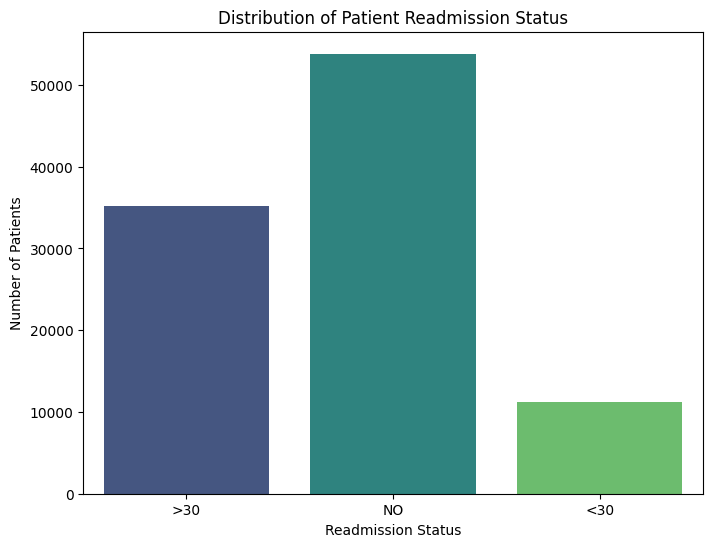

In [9]:
# distribution of the target variable 'readmitted'
readmitted_counts = diabetes__clean_data_df['readmitted'].value_counts()
readmitted_percentages = diabetes__clean_data_df['readmitted'].value_counts(normalize=True) * 100

print("Distribution of 'readmitted' column:")
display(readmitted_counts)
print("\nPercentage distribution of 'readmitted' column:")
display(readmitted_percentages)

# Visz
plt.figure(figsize=(8, 6))
sns.countplot(data=diabetes__clean_data_df, x='readmitted', hue='readmitted', palette='viridis', legend=False)
plt.title('Distribution of Patient Readmission Status')
plt.xlabel('Readmission Status')
plt.ylabel('Number of Patients')
plt.show()

###Readmissions by race, gender, Age

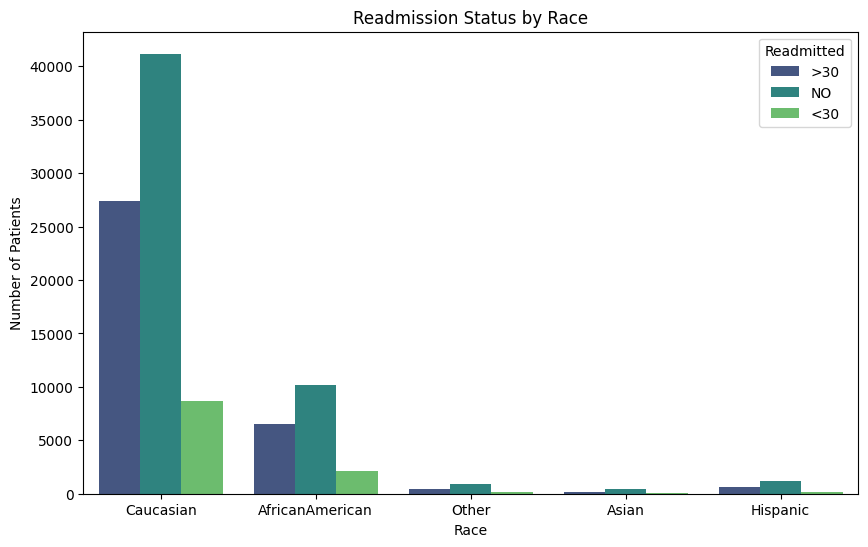

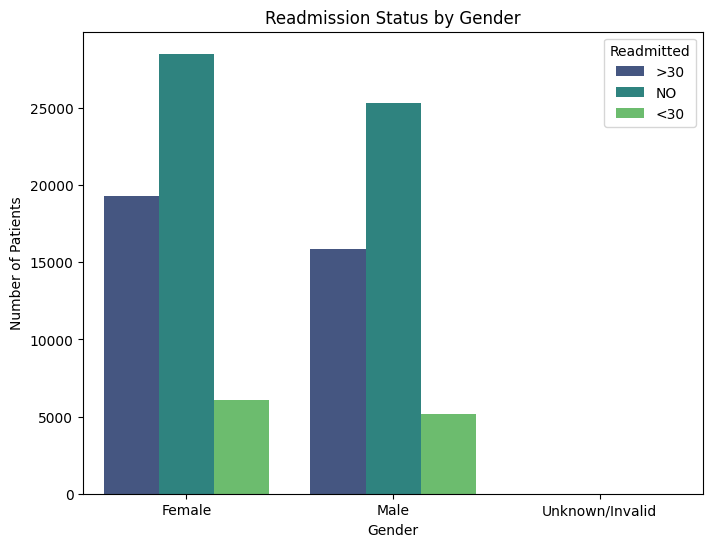

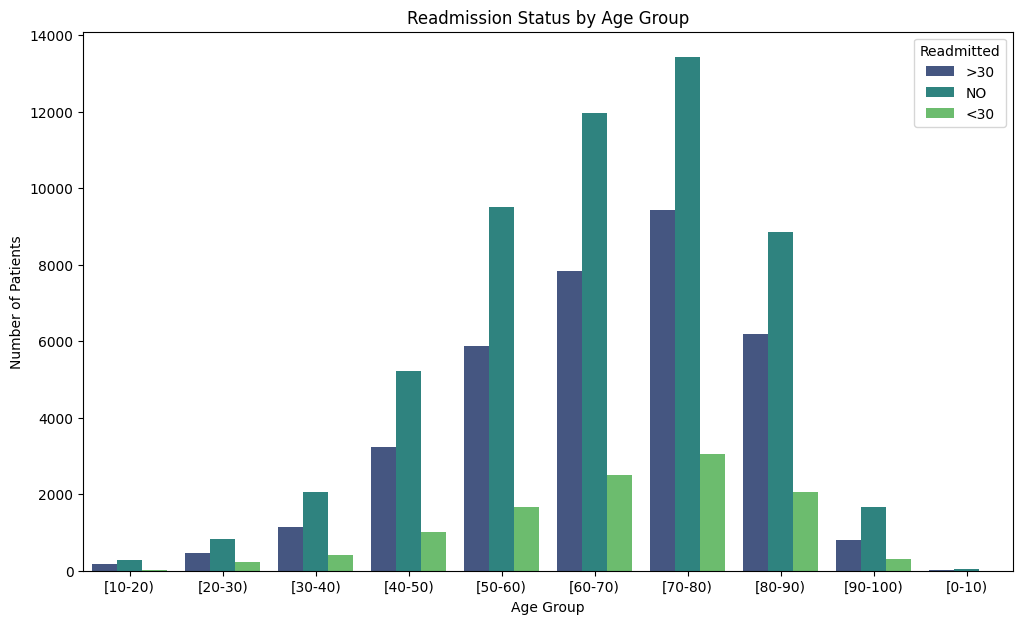

In [10]:
#Readmission by Race

plt.figure(figsize=(10, 6))
sns.countplot(data=diabetes__clean_data_df, x='race', hue='readmitted', palette='viridis')
plt.title('Readmission Status by Race')
plt.xlabel('Race')
plt.ylabel('Number of Patients')
plt.legend(title='Readmitted')
plt.show()

#readmission by gender
plt.figure(figsize=(8, 6))
sns.countplot(data=diabetes__clean_data_df, x='gender', hue='readmitted', palette='viridis')
plt.title('Readmission Status by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Patients')
plt.legend(title='Readmitted')
plt.show()

#readmission by age

plt.figure(figsize=(12, 7))
sns.countplot(data=diabetes__clean_data_df, x='age', hue='readmitted', palette='viridis')
plt.title('Readmission Status by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Patients')
plt.legend(title='Readmitted')
plt.show()

###Readmission by Change in med vs no change in med, on med vs not


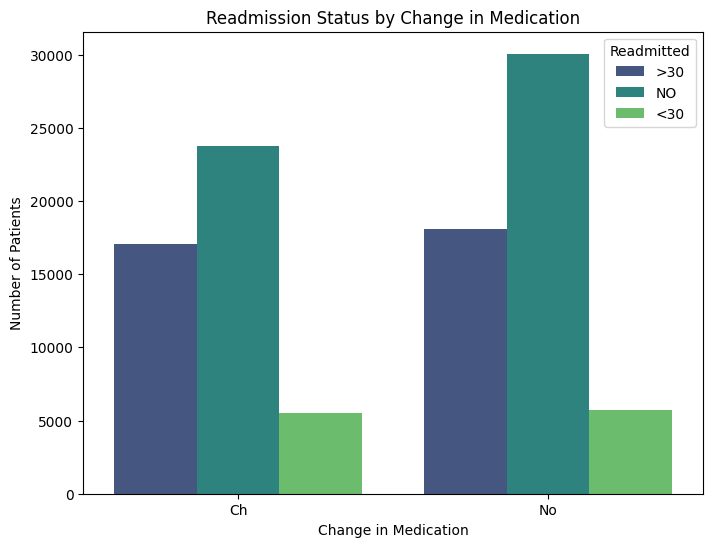

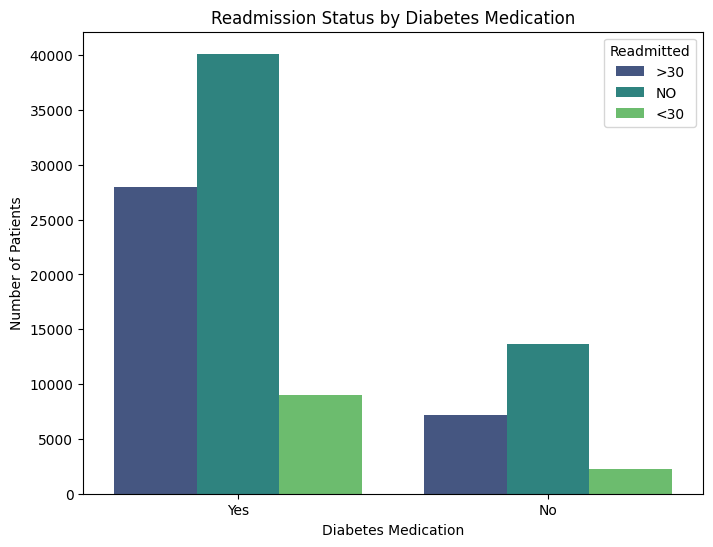

In [11]:
#readmissions vs whether there was a change in med or not
plt.figure(figsize=(8, 6))
sns.countplot(data=diabetes__clean_data_df, x='change', hue='readmitted', palette='viridis')
plt.title('Readmission Status by Change in Medication')
plt.xlabel('Change in Medication')
plt.ylabel('Number of Patients')
plt.legend(title='Readmitted')
plt.show()


#readmissions vs whether patient was on diabetes medication or not
plt.figure(figsize=(8, 6))
sns.countplot(data=diabetes__clean_data_df, x='diabetesMed', hue='readmitted', palette='viridis')
plt.title('Readmission Status by Diabetes Medication')
plt.xlabel('Diabetes Medication')
plt.ylabel('Number of Patients')
plt.legend(title='Readmitted')
plt.show()

### Numerical cols vs. Readmission




/tmp/ipython-input-1977141110.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=diabetes__clean_data_df, x='readmitted', y=feature, palette='viridis')


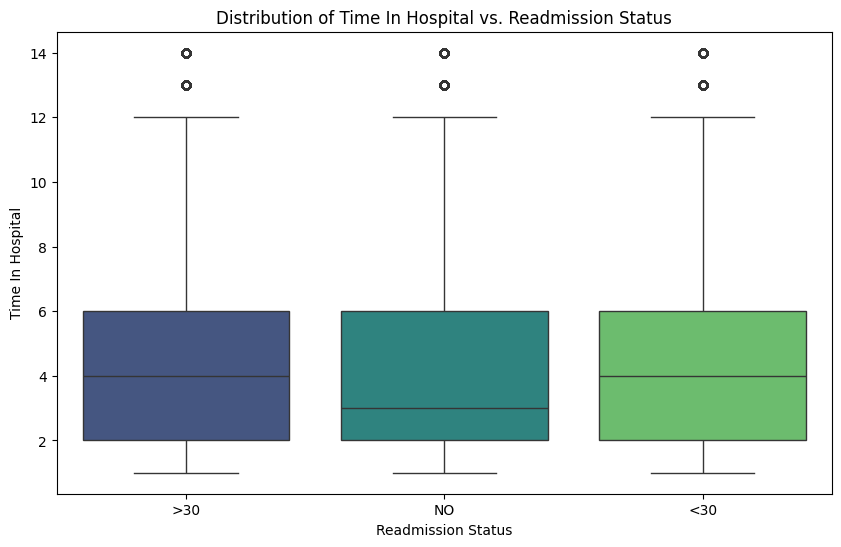

/tmp/ipython-input-1977141110.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=diabetes__clean_data_df, x='readmitted', y=feature, palette='viridis')


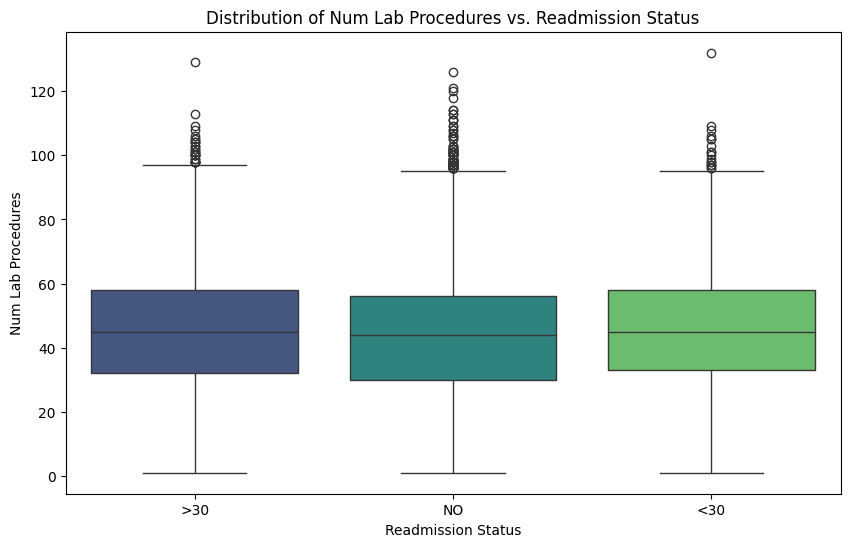

/tmp/ipython-input-1977141110.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=diabetes__clean_data_df, x='readmitted', y=feature, palette='viridis')


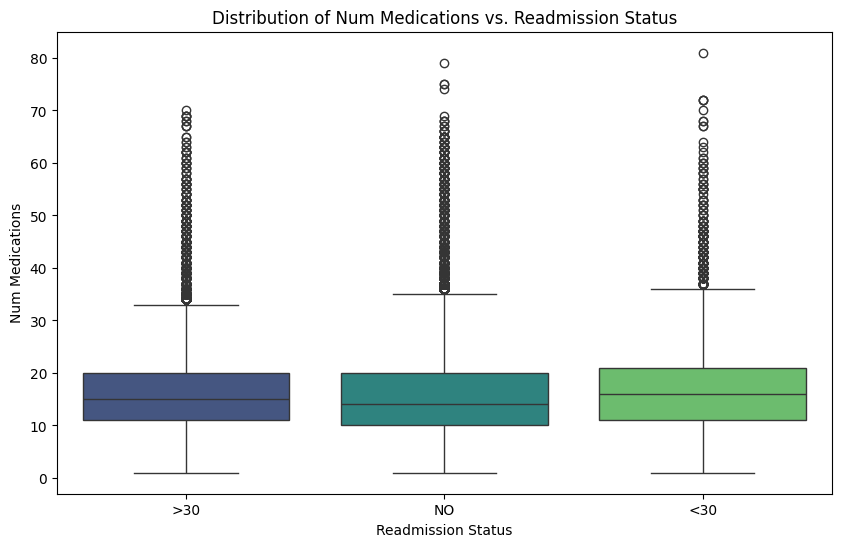

/tmp/ipython-input-1977141110.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=diabetes__clean_data_df, x='readmitted', y=feature, palette='viridis')


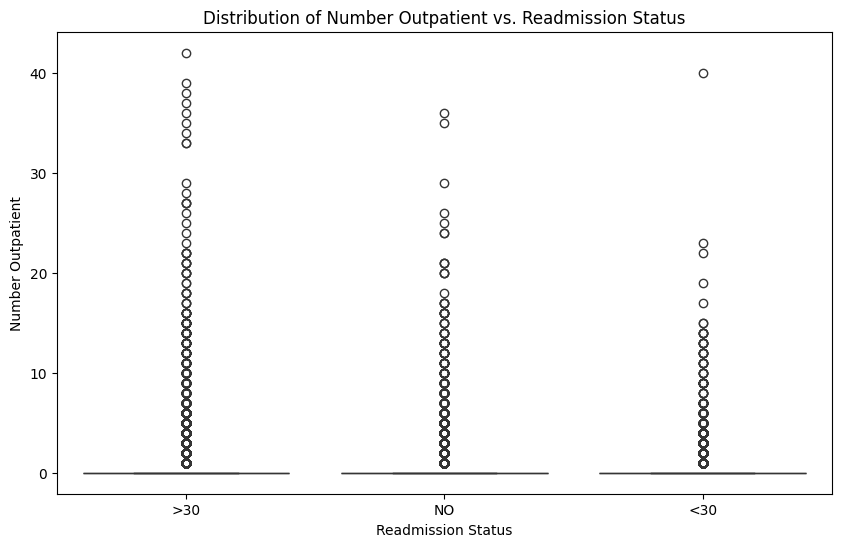

/tmp/ipython-input-1977141110.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=diabetes__clean_data_df, x='readmitted', y=feature, palette='viridis')


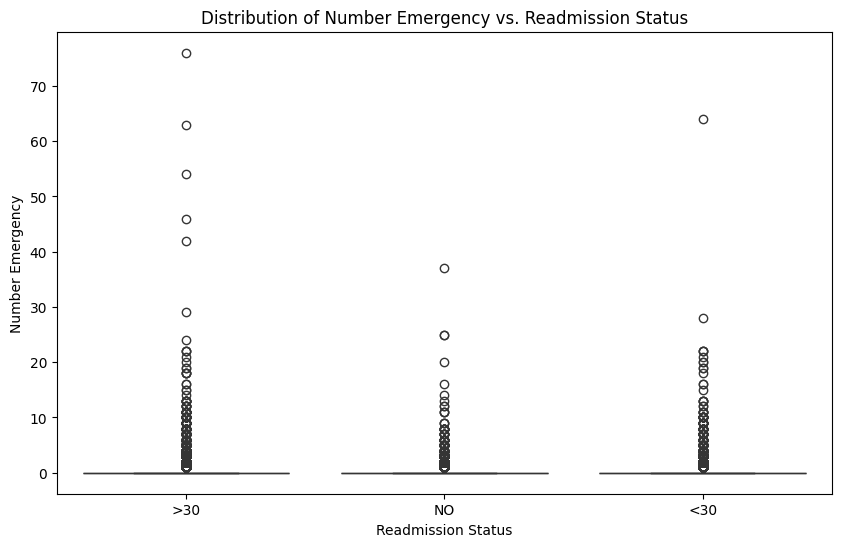

/tmp/ipython-input-1977141110.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=diabetes__clean_data_df, x='readmitted', y=feature, palette='viridis')


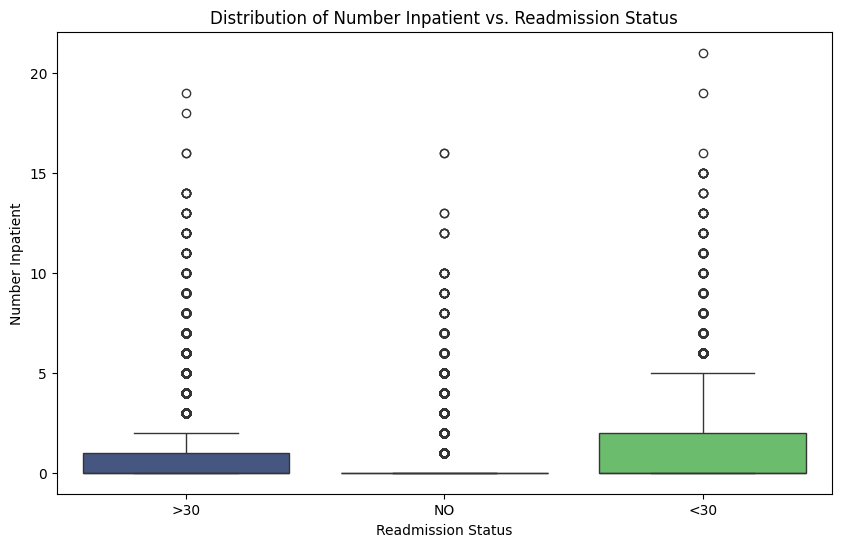

In [12]:
numerical_features = ['time_in_hospital', 'num_lab_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient']

for feature in numerical_features:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=diabetes__clean_data_df, x='readmitted', y=feature, palette='viridis')
    plt.title(f'Distribution of {feature.replace("_", " ").title()} vs. Readmission Status')
    plt.xlabel('Readmission Status')
    plt.ylabel(f'{feature.replace("_", " ").title()}')
    plt.show()

## Creating a new feature

### Total visits= outpatient, inpatient, emergency

,total_prior_visits
1,0
2,3
3,0
4,0
5,0


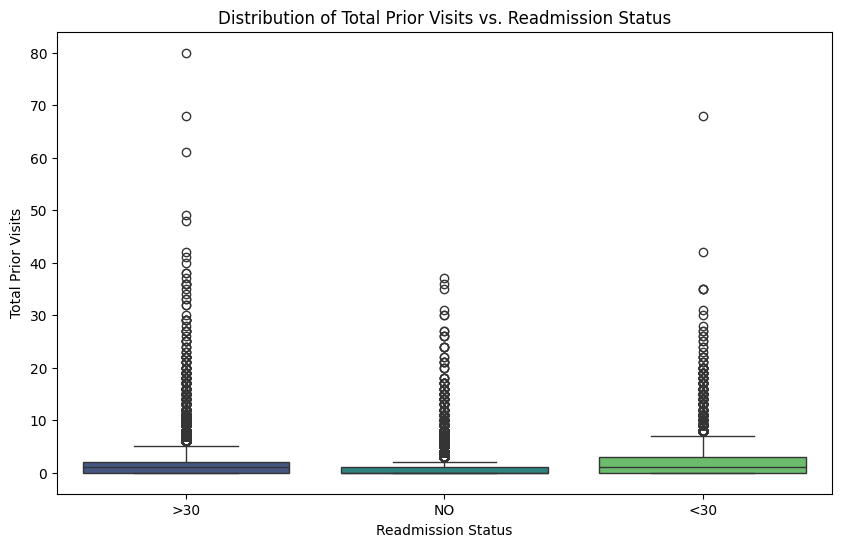

In [13]:
diabetes__clean_data_df['total_prior_visits'] = diabetes__clean_data_df['number_outpatient'] + diabetes__clean_data_df['number_emergency'] + diabetes__clean_data_df['number_inpatient']
diabetes__clean_data_df = diabetes__clean_data_df.drop(columns=['number_outpatient', 'number_emergency', 'number_inpatient'])
display(diabetes__clean_data_df[['total_prior_visits']].head())

plt.figure(figsize=(10, 6))
sns.boxplot(data=diabetes__clean_data_df, x='readmitted', y='total_prior_visits', hue='readmitted', palette='viridis', legend=False)
plt.title('Distribution of Total Prior Visits vs. Readmission Status')
plt.xlabel('Readmission Status')
plt.ylabel('Total Prior Visits')
plt.show()

##Preprocessing

###Mapping target Variable

In [14]:
diabetes__clean_data_df.shape

(100244, 43)

In [15]:

print("Before mapping, unique values and their counts in 'readmitted':")
display(diabetes__clean_data_df['readmitted'].value_counts(dropna=False))

#Combining > and <30
readmitted_mapping = {
    'NO': 0,
    '>30': 1,
    '<30': 1
}

diabetes__clean_data_df['readmitted'] = diabetes__clean_data_df['readmitted'].map(readmitted_mapping)

print("\nAfter mapping, value counts:")
display(diabetes__clean_data_df['readmitted'].value_counts(dropna=False))
print("After mapping, unique values:")
display(diabetes__clean_data_df['readmitted'].unique())


if diabetes__clean_data_df['readmitted'].isnull().any():

  #Gemini generated this section of the code because I had issues with loading the data set

    # If there are NaNs, it means some values in the original column were not in the mapping.
    # We should identify and handle them. For now, let's drop rows with NaNs in the target.
    print("\nWARNING: NaNs found in 'readmitted' column after mapping. Dropping rows with NaNs in target.")
    diabetes__clean_data_df.dropna(subset=['readmitted'], inplace=True)
else:
    print("\nNo NaNs found in 'readmitted' column after mapping.")

# Ensure the column is an integer type
diabetes__clean_data_df['readmitted'] = diabetes__clean_data_df['readmitted'].astype(int)

Before mapping, unique values and their counts in 'readmitted':


,count
readmitted,
NO,53821
>30,35173
<30,11250



After mapping, value counts:


,count
readmitted,
0,53821
1,46423


After mapping, unique values:


array([1, 0])


No NaNs found in 'readmitted' column after mapping.


###Prepping X and Y

In [16]:
X = diabetes__clean_data_df.drop(['readmitted', 'encounter_id', 'patient_nbr'], axis=1)
y = diabetes__clean_data_df['readmitted']

print("Shape of features (X):", X.shape)
print("Shape of target (y):", y.shape)
display(X.head())
display(y.head())

Shape of features (X): (100244, 40)
Shape of target (y): (100244,)


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,total_prior_visits
1,Caucasian,Female,[10-20),1,1,7,3,59,0,18,...,No,Up,No,No,No,No,No,Ch,Yes,0
2,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,13,...,No,No,No,No,No,No,No,No,Yes,3
3,Caucasian,Male,[30-40),1,1,7,2,44,1,16,...,No,Up,No,No,No,No,No,Ch,Yes,0
4,Caucasian,Male,[40-50),1,1,7,1,51,0,8,...,No,Steady,No,No,No,No,No,Ch,Yes,0
5,Caucasian,Male,[50-60),2,1,2,3,31,6,16,...,No,Steady,No,No,No,No,No,No,Yes,0


,readmitted
1,1
2,0
3,0
4,0
5,1


###Had Gemini check for suggestions of  other columns that I could drop.

 It ran this code and what this code does is, it  essentially goes through each of the  text-based column one by one, prints the name of the column, shows how many unique values it contains, and then shows the top ten most common ones.
 The basic idea is to see if any column has too many categories before I try to encode them for modeling. If it doesn't it won't exactly contribute to the variance in the big way.
 Kind of manual dimensional reduction in a way

In [17]:
print("Checking categorical features in X for high cardinality:")
for col in X.select_dtypes(include='object').columns:
    print(f"\n--- Column: {col} ---")
    print(f"Number of unique values: {X[col].nunique()}")
    # Display top 10 value counts for brevity
    display(X[col].value_counts().head(10))

Checking categorical features in X for high cardinality:

--- Column: race ---
Number of unique values: 5


,count
race,
Caucasian,77270
AfricanAmerican,18881
Hispanic,1984
Other,1484
Asian,625



--- Column: gender ---
Number of unique values: 3


,count
gender,
Female,53922
Male,46319
Unknown/Invalid,3



--- Column: age ---
Number of unique values: 10


...

,count
metformin-pioglitazone,
No,100243
Steady,1



--- Column: change ---
Number of unique values: 2


,count
change,
No,53892
Ch,46352



--- Column: diabetesMed ---
Number of unique values: 2


,count
diabetesMed,
Yes,77155
No,23089


###dropping identified columns

In [18]:
columns_to_drop_from_X = [
    'acetohexamide', 'tolbutamide', 'troglitazone', 'examide', 'citoglipton',
    'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone',
    'metformin-pioglitazone', 'tolazamide', 'miglitol', 'acarbose'
]
X = diabetes__clean_data_df.drop(columns_to_drop_from_X, axis=1)
y = diabetes__clean_data_df['readmitted']

print("Shape of features (X) after dropping specific columns:", X.shape)
print("Shape of target (y):", y.shape)
display(X.head())
display(y.head())

Shape of features (X) after dropping specific columns: (100244, 31)
Shape of target (y): (100244,)


,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,glipizide,glyburide,pioglitazone,rosiglitazone,insulin,glyburide-metformin,change,diabetesMed,readmitted,total_prior_visits
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,59,...,No,No,No,No,Up,No,Ch,Yes,1,0
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,11,...,Steady,No,No,No,No,No,No,Yes,0,3
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,44,...,No,No,No,No,Up,No,Ch,Yes,0,0
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,51,...,Steady,No,No,No,Steady,No,Ch,Yes,0,0
5,35754,82637451,Caucasian,Male,[50-60),2,1,2,3,31,...,No,No,No,No,Steady,No,No,Yes,1,0


,readmitted
1,1
2,0
3,0
4,0
5,1


###Binary Encoding for X

In [19]:
categorical_features = X.select_dtypes(include='object').columns
X_encoded = pd.get_dummies(X, columns=categorical_features, drop_first=True)

print("Shape of X after one-hot encoding:", X_encoded.shape)
display(X_encoded.head())

Shape of X after one-hot encoding: (100244, 2306)


,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_diagnoses,...,rosiglitazone_Steady,rosiglitazone_Up,insulin_No,insulin_Steady,insulin_Up,glyburide-metformin_No,glyburide-metformin_Steady,glyburide-metformin_Up,change_No,diabetesMed_Yes
1,149190,55629189,1,1,7,3,59,0,18,9,...,False,False,False,False,True,True,False,False,False,True
2,64410,86047875,1,1,7,2,11,5,13,6,...,False,False,True,False,False,True,False,False,True,True
3,500364,82442376,1,1,7,2,44,1,16,7,...,False,False,False,False,True,True,False,False,False,True
4,16680,42519267,1,1,7,1,51,0,8,5,...,False,False,False,True,False,True,False,False,False,True
5,35754,82637451,2,1,2,3,31,6,16,9,...,False,False,False,True,False,True,False,False,True,True


###Split into Train, Test Val

In [20]:

#  training (70%) and  (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_encoded, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5, # 50% of the temporary set
    random_state=42,
    stratify=y_temp
)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_val: {X_val.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_val: {y_val.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (70170, 2306)
Shape of X_val: (15037, 2306)
Shape of X_test: (15037, 2306)
Shape of y_train: (70170,)
Shape of y_val: (15037,)
Shape of y_test: (15037,)


##Normalize

In [21]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
numerical_cols = X_encoded.select_dtypes(include=np.number).columns
X_scaled = scaler.fit_transform(X_encoded[numerical_cols])
X_scaled_for_pca = pd.DataFrame(X_scaled, columns=numerical_cols, index=X_encoded.index)

##PCA

In [22]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(X_scaled_for_pca)
cum_explained_variance = np.cumsum(pca.explained_variance_ratio_)
variance_threshold_90 = 0.90
num_components_90 = np.argmax(cum_explained_variance >= variance_threshold_90) + 1

pca = PCA(n_components=num_components_90)
X_pca = pca.fit_transform(X_scaled_for_pca)
X_pca = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(num_components_90)], index=X_scaled_for_pca.index)

print("Post PCA shape", X_pca.shape)
display(X_pca.head())

Post PCA shape (100244, 10)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
1,0.014037,-0.245541,1.286097,-0.984324,-0.329621,-0.843722,-1.053638,0.568082,-0.074504,0.768987
2,-1.044778,-0.368163,-1.010478,0.972538,-0.599826,-0.491320,1.324131,1.173752,1.093952,-0.873210
3,-0.914010,-0.261357,-0.278607,-0.737057,0.454999,-0.698625,0.120811,0.147142,0.242868,0.117160
4,-2.251351,-0.749579,0.078414,-1.350322,0.175143,-0.770680,0.292583,-0.450290,0.459944,0.135219
5,0.558644,-0.535136,-1.117186,1.091506,-1.501488,-0.706748,-1.032519,1.693178,0.902716,0.654720


###PCA Loadings

In [23]:
pca_loadings = pd.DataFrame(pca.components_, columns=X_scaled_for_pca.columns, index=[f'PC{i+1}' for i in range(num_components_90)])

print("PCA Loadings (Contribution of original features to each Principal Component):")
display(pca_loadings)


print("\nTop features contributing to each Principal Component (absolute value):")
for i in range(num_components_90):
    pc_name = f'PC{i+1}'
    top_features = pca_loadings.loc[pc_name].abs().sort_values(ascending=False).head(5)
    print(f"\n{pc_name}:\n{top_features}")

PCA Loadings (Contribution of original features to each Principal Component):


,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_diagnoses,readmitted,total_prior_visits
PC1,0.171208,0.164013,-0.047404,0.106058,-0.041192,0.483526,0.362643,0.302282,0.535623,0.395461,0.109265,0.129203
PC2,0.569763,0.535995,-0.235788,-0.286394,-0.055450,-0.233593,-0.092475,-0.211620,-0.172485,0.249661,0.092293,0.197199
PC3,-0.228539,-0.120968,-0.042962,0.140931,0.495698,0.061967,0.154216,-0.425089,-0.124479,0.160152,0.473704,0.438008
PC4,0.052151,0.209024,0.721596,0.053758,0.132788,-0.121133,-0.435991,0.286975,0.131319,-0.013157,0.209451,0.252907
PC5,0.138710,0.183188,0.208771,0.221414,0.612140,0.028803,0.076951,-0.168489,-0.038677,0.224905,-0.528019,-0.337425
PC6,0.134642,-0.024830,-0.117195,0.821076,-0.346503,0.018302,-0.303287,-0.181516,-0.058685,0.135245,-0.087564,0.136458
PC7,0.051877,-0.256203,-0.102294,-0.152200,0.090974,-0.040182,-0.047269,0.097005,0.100033,-0.061021,-0.600345,0.708774
PC8,-0.080762,-0.324313,-0.342935,-0.100814,0.218588,-0.163331,-0.471506,0.339649,0.015678,0.556864,0.099188,-0.167965
PC9,0.079063,0.116452,-0.218656,0.354154,0.227644,-0.510698,0.375369,0.524365,-0.090658,-0.230453,0.113572,0.065048
PC10,-0.181138,-0.138329,0.376712,-0.044807,-0.355348,-0.399410,0.408091,-0.050679,-0.170797,0.553772,-0.105512,0.047534



Top features contributing to each Principal Component (absolute value):

PC1:
num_medications       0.535623
time_in_hospital      0.483526
number_diagnoses      0.395461
num_lab_procedures    0.362643
num_procedures        0.302282
Name: PC1, dtype: float64

PC2:
encounter_id                0.569763
patient_nbr                 0.535995
discharge_disposition_id    0.286394
number_diagnoses            0.249661
admission_type_id           0.235788
Name: PC2, dtype: float64

PC3:
admission_source_id    0.495698
readmitted             0.473704
total_prior_visits     0.438008
num_procedures         0.425089
encounter_id           0.228539
Name: PC3, dtype: float64

PC4:
admission_type_id     0.721596
num_lab_procedures    0.435991
num_procedures        0.286975
total_prior_visits    0.252907
readmitted            0.209451
Name: PC4, dtype: float64

PC5:
admission_source_id         0.612140
readmitted                  0.528019
total_prior_visits          0.337425
number_diagnoses           

##PCA Split

In [24]:

X_train_pca = X_pca.loc[X_train.index]
X_val_pca = X_pca.loc[X_val.index]
X_test_pca = X_pca.loc[X_test.index]

print(f"Shape of X_train_pca: {X_train_pca.shape}")
print(f"Shape of X_val_pca: {X_val_pca.shape}")
print(f"Shape of X_test_pca: {X_test_pca.shape}")

Shape of X_train_pca: (70170, 10)
Shape of X_val_pca: (15037, 10)
Shape of X_test_pca: (15037, 10)


## Class weights

In [25]:
classes_pca = np.unique(y_train)
class_weights_pca = compute_class_weight(class_weight='balanced', classes=classes_pca, y=y_train)
class_weights_dict_pca = dict(zip(classes_pca, class_weights_pca))
print("Computed class weights for (PCA) training set:")
display(class_weights_dict_pca)

Computed class weights for (PCA) training set:


{np.int64(0): np.float64(0.9312788660614748),
 np.int64(1): np.float64(1.0796713441654358)}

## Classification Model Registry



In [26]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

def build_classification_registry(class_weights_dict):

    registry = {}

    # 1. Logistic Regression
    lr_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(random_state=42)),
        ('logisticregression', LogisticRegression(random_state=42, solver='liblinear', max_iter=200, class_weight=class_weights_dict))
    ])
    lr_param_grid = {
        'pca__n_components': [5, 9],
        'logisticregression__C': [0.1, 1, 10]
    }
    registry['Logistic Regression'] = {'pipeline': lr_pipeline, 'param_grid': lr_param_grid}

    # 2. Decision Tree
    dt_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(random_state=42)),
        ('decisiontreeclassifier', DecisionTreeClassifier(random_state=42, class_weight=class_weights_dict))
    ])
    dt_param_grid = {
        'pca__n_components': [5, 9],
        'decisiontreeclassifier__max_depth': [None, 10, 20],
        'decisiontreeclassifier__min_samples_split': [2, 5]
    }
    registry['Decision Tree'] = {'pipeline': dt_pipeline, 'param_grid': dt_param_grid}

    # 3. Random Forest
    rf_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(random_state=42)),
        ('randomforestclassifier', RandomForestClassifier(random_state=42, class_weight=class_weights_dict))
    ])
    rf_param_grid = {
        'pca__n_components': [5, 9],
        'randomforestclassifier__n_estimators': [50, 100],
        'randomforestclassifier__max_depth': [None, 10]
    }
    registry['Random Forest'] = {'pipeline': rf_pipeline, 'param_grid': rf_param_grid}

    return registry

# Call the function with class_weights_dict_binary
model_registry = build_classification_registry(class_weights_dict_pca)

print("Model registry created successfully.")
print(f"Number of models in registry: {len(model_registry)}")


Model registry created successfully.
Number of models in registry: 3


###Grid Search



In [27]:
from sklearn.model_selection import GridSearchCV

results = {}

for model_name, model_info in model_registry.items():
    print(f"\n------ Tuning {model_name} ------")
    pipeline = model_info['pipeline']
    param_grid = model_info['param_grid']


    grid_search = GridSearchCV(estimator=pipeline,
                               param_grid=param_grid,
                               cv=3,
                               scoring='f1_weighted',
                               n_jobs=2, # Gemini made this change : Changed from -1 to 2 to prevent resource issues
                               verbose=1)


    grid_search.fit(X_train, y_train)


    results[model_name] = {
        'best_estimator': grid_search.best_estimator_,
        'best_score': grid_search.best_score_,
        'best_params': grid_search.best_params_,
        'cv_results': grid_search.cv_results_
    }

    print(f"Finished tuning {model_name}. Best F1-weighted score: {grid_search.best_score_:.4f}")
    print(f"Best parameters: {grid_search.best_params_}")

print("\n------ All models tuned. ------")


------ Tuning Logistic Regression ------
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Finished tuning Logistic Regression. Best F1-weighted score: 0.6063
Best parameters: {'logisticregression__C': 10, 'pca__n_components': 9}

------ Tuning Decision Tree ------
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Finished tuning Decision Tree. Best F1-weighted score: 0.5924
Best parameters: {'decisiontreeclassifier__max_depth': 10, 'decisiontreeclassifier__min_samples_split': 2, 'pca__n_components': 9}

------ Tuning Random Forest ------
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Finished tuning Random Forest. Best F1-weighted score: 0.6322
Best parameters: {'pca__n_components': 9, 'randomforestclassifier__max_depth': None, 'randomforestclassifier__n_estimators': 100}

------ All models tuned. ------


### Evaluation of Models on Validation Set

In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

validation_results = {}

print("\n------ Evaluating models on Validation Set ------")

for model_name, model_info in results.items():
    print(f"\n--- Evaluating {model_name} ---")
    best_model = model_info['best_estimator']

    # predictions
    y_pred_val = best_model.predict(X_val)

    # performance metrics
    accuracy = accuracy_score(y_val, y_pred_val)
    precision = precision_score(y_val, y_pred_val, average='weighted', zero_division=0)
    recall = recall_score(y_val, y_pred_val, average='weighted', zero_division=0)
    f1 = f1_score(y_val, y_pred_val, average='weighted', zero_division=0)


    roc_auc = None
    if hasattr(best_model, 'predict_proba') and len(best_model.classes_) == 2:
        y_pred_proba_val = best_model.predict_proba(X_val)[:, 1]
        roc_auc = roc_auc_score(y_val, y_pred_proba_val)

    validation_results[model_name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_weighted': f1,
        'roc_auc': roc_auc,
        'confusion_matrix': confusion_matrix(y_val, y_pred_val),
        'classification_report': classification_report(y_val, y_pred_val, zero_division=0)
    }

    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision (weighted): {precision:.4f}")
    print(f"  Recall (weighted): {recall:.4f}")
    print(f"  F1-Score (weighted): {f1:.4f}")
    if roc_auc is not None:
        print(f"  ROC AUC: {roc_auc:.4f}")
    print("  Confusion Matrix:\n", validation_results[model_name]['confusion_matrix'])
    print("  Classification Report:\n", validation_results[model_name]['classification_report'])

print("\n------ Validation evaluation complete. ------")


------ Evaluating models on Validation Set ------

--- Evaluating Logistic Regression ---
  Accuracy: 0.6020
  Precision (weighted): 0.6075
  Recall (weighted): 0.6020
  F1-Score (weighted): 0.6022
  ROC AUC: 0.6493
  Confusion Matrix:
 [[4595 3478]
 [2507 4457]]
  Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.57      0.61      8073
           1       0.56      0.64      0.60      6964

    accuracy                           0.60     15037
   macro avg       0.60      0.60      0.60     15037
weighted avg       0.61      0.60      0.60     15037


--- Evaluating Decision Tree ---
  Accuracy: 0.5825
  Precision (weighted): 0.5858
  Recall (weighted): 0.5825
  F1-Score (weighted): 0.5830
  ROC AUC: 0.6219
  Confusion Matrix:
 [[4609 3464]
 [2814 4150]]
  Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.57      0.59      8073
           1       0.55      0.60      

### Final Evaluation on Test Set

In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

print("\n------ Evaluating the Best Model on Test Set ------")

best_model_name = max(validation_results, key=lambda name: validation_results[name]['f1_weighted'])
best_model_info = results[best_model_name]
best_final_model = best_model_info['best_estimator']

print(f"The best model selected from validation is: {best_model_name}")
print(f"Best parameters from GridSearch for {best_model_name}: {best_model_info['best_params']}")

# predictions on the test
y_pred_test = best_final_model.predict(X_test)

#  performance metrics
accuracy_test = accuracy_score(y_test, y_pred_test)
precision_test = precision_score(y_test, y_pred_test, average='weighted', zero_division=0)
recall_test = recall_score(y_test, y_pred_test, average='weighted', zero_division=0)
f1_test = f1_score(y_test, y_pred_test, average='weighted', zero_division=0)

roc_auc_test = None
if hasattr(best_final_model, 'predict_proba') and len(best_final_model.classes_) == 2:
    y_pred_proba_test = best_final_model.predict_proba(X_test)[:, 1]
    roc_auc_test = roc_auc_score(y_test, y_pred_proba_test)

print(f"\n--- Test Set Evaluation for {best_model_name} ---")
print(f"  Accuracy: {accuracy_test:.4f}")
print(f"  Precision (weighted): {precision_test:.4f}")
print(f"  Recall (weighted): {recall_test:.4f}")
print(f"  F1-Score (weighted): {f1_test:.4f}")
if roc_auc_test is not None:
    print(f"  ROC AUC: {roc_auc_test:.4f}")
print("  Confusion Matrix:\n", confusion_matrix(y_test, y_pred_test))
print("  Classification Report:\n", classification_report(y_test, y_pred_test, zero_division=0))

print("\n------ Test set evaluation complete. ------")


------ Evaluating the Best Model on Test Set ------
The best model selected from validation is: Random Forest
Best parameters from GridSearch for Random Forest: {'pca__n_components': 9, 'randomforestclassifier__max_depth': None, 'randomforestclassifier__n_estimators': 100}

--- Test Set Evaluation for Random Forest ---
  Accuracy: 0.6373
  Precision (weighted): 0.6361
  Recall (weighted): 0.6373
  F1-Score (weighted): 0.6340
  ROC AUC: 0.6843
  Confusion Matrix:
 [[5830 2244]
 [3210 3753]]
  Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.72      0.68      8074
           1       0.63      0.54      0.58      6963

    accuracy                           0.64     15037
   macro avg       0.64      0.63      0.63     15037
weighted avg       0.64      0.64      0.63     15037


------ Test set evaluation complete. ------


###decison Tree tree map for viz

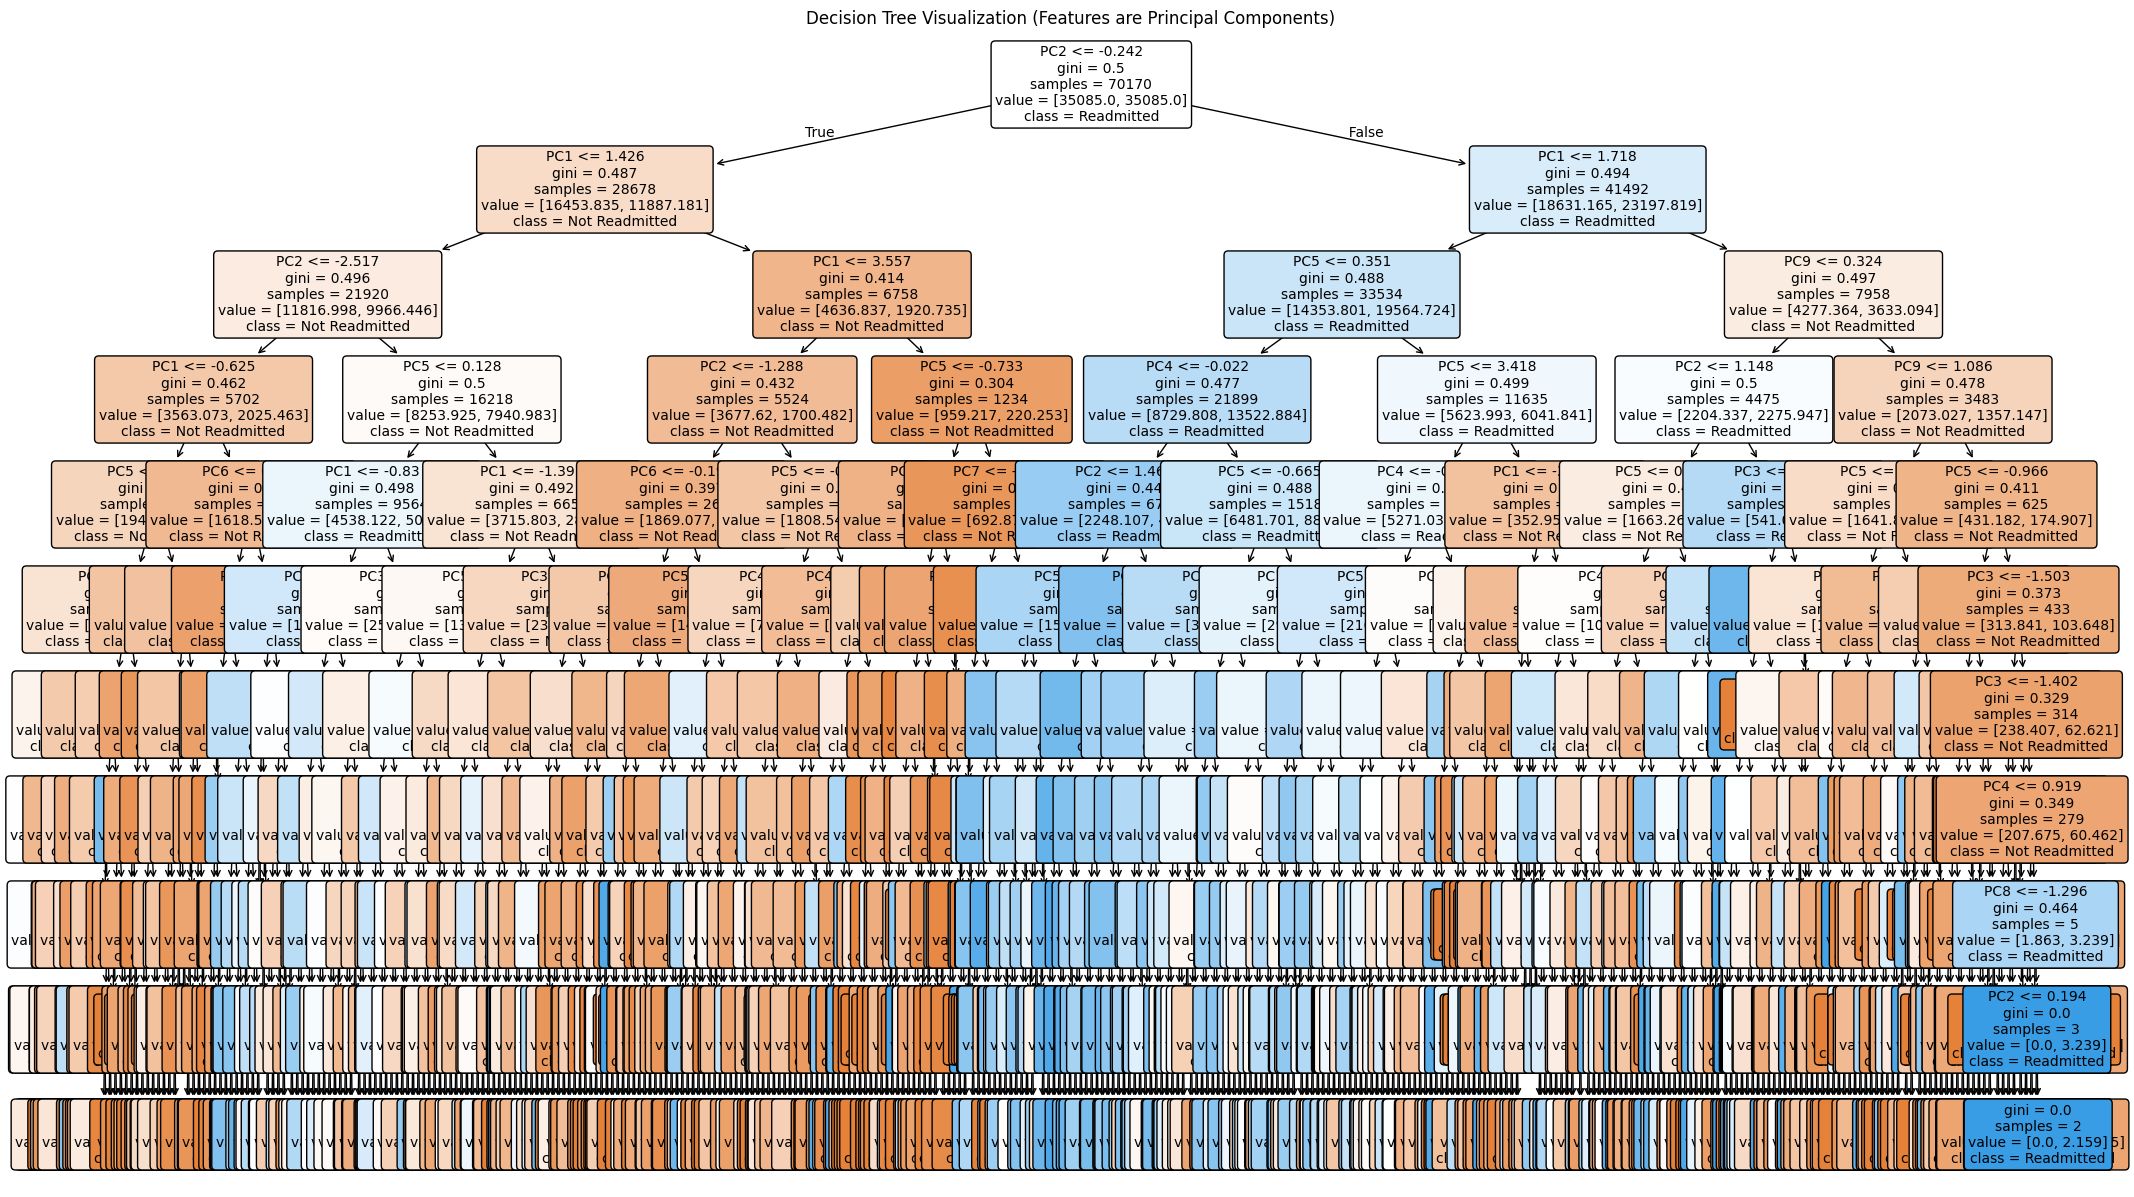

In [30]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

best_dt_pipeline = results['Decision Tree']['best_estimator']

best_dt_model = best_dt_pipeline.named_steps['decisiontreeclassifier']

pca_component = best_dt_pipeline.named_steps['pca']
pca_n_components = pca_component.n_components

feature_names_for_tree = [f'PC{i+1}' for i in range(pca_n_components)]
class_names = ['Not Readmitted', 'Readmitted']

plt.figure(figsize=(25, 15))
plot_tree(best_dt_model,
          feature_names=feature_names_for_tree,
          class_names=class_names,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Decision Tree Visualization (Features are Principal Components)')
plt.show()


In [31]:
diabetes__clean_data_df.shape


(100244, 43)

## KNN

###Sampling and Split

In [32]:
from sklearn.model_selection import train_test_split

# Sample
X_encoded_knn, X_temp_discard, y_encoded_knn, y_temp_discard = train_test_split(
    X_encoded,
    y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

print(f"Shape of X_encoded_knn (15% sample): {X_encoded_knn.shape}")
print(f"Shape of y_encoded_knn (15% sample): {y_encoded_knn.shape}")

# Split
X_knn_train_raw, X_knn_temp_raw, y_knn_train_raw, y_knn_temp_raw = train_test_split(
    X_encoded_knn,
    y_encoded_knn,
    train_size=0.7,
    random_state=42,
    stratify=y_encoded_knn
)

X_knn_val_raw, X_knn_test_raw, y_knn_val_raw, y_knn_test_raw = train_test_split(
    X_knn_temp_raw,
    y_knn_temp_raw,
    test_size=0.5,
    random_state=42,
    stratify=y_knn_temp_raw
)

# Step 4: Print shapes to confirm splits
print(f"Shape of X_knn_train_raw: {X_knn_train_raw.shape}")
print(f"Shape of y_knn_train_raw: {y_knn_train_raw.shape}")
print(f"Shape of X_knn_val_raw: {X_knn_val_raw.shape}")
print(f"Shape of y_knn_val_raw: {y_knn_val_raw.shape}")
print(f"Shape of X_knn_test_raw: {X_knn_test_raw.shape}")
print(f"Shape of y_knn_test_raw: {y_knn_test_raw.shape}")

Shape of X_encoded_knn (15% sample): (85207, 2306)
Shape of y_encoded_knn (15% sample): (85207,)
Shape of X_knn_train_raw: (59644, 2306)
Shape of y_knn_train_raw: (59644,)
Shape of X_knn_val_raw: (12781, 2306)
Shape of y_knn_val_raw: (12781,)
Shape of X_knn_test_raw: (12782, 2306)
Shape of y_knn_test_raw: (12782,)


###Normalizing and PCA

In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


scaler_knn = StandardScaler()
pca_knn = PCA(n_components=10, random_state=42)


X_knn_train_scaled = scaler_knn.fit_transform(X_knn_train_raw)
X_knn_train_pca = pca_knn.fit_transform(X_knn_train_scaled)

#  validation set
X_knn_val_scaled = scaler_knn.transform(X_knn_val_raw)
X_knn_val_pca = pca_knn.transform(X_knn_val_scaled)

#  test set
X_knn_test_scaled = scaler_knn.transform(X_knn_test_raw)
X_knn_test_pca = pca_knn.transform(X_knn_test_scaled)


X_knn_train_pca_df = pd.DataFrame(X_knn_train_pca, columns=[f'PC{i+1}' for i in range(X_knn_train_pca.shape[1])], index=X_knn_train_raw.index)
X_knn_val_pca_df = pd.DataFrame(X_knn_val_pca, columns=[f'PC{i+1}' for i in range(X_knn_val_pca.shape[1])], index=X_knn_val_raw.index)
X_knn_test_pca_df = pd.DataFrame(X_knn_test_pca, columns=[f'PC{i+1}' for i in range(X_knn_test_pca.shape[1])], index=X_knn_test_raw.index)

print(f"Shape of X_knn_train_pca_df: {X_knn_train_pca_df.shape}")
print(f"Shape of X_knn_val_pca_df: {X_knn_val_pca_df.shape}")
print(f"Shape of X_knn_test_pca_df: {X_knn_test_pca_df.shape}")

print("First 5 rows of X_knn_train_pca_df:")
display(X_knn_train_pca_df.head())


Shape of X_knn_train_pca_df: (59644, 10)
Shape of X_knn_val_pca_df: (12781, 10)
Shape of X_knn_test_pca_df: (12782, 10)
First 5 rows of X_knn_train_pca_df:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
74646,-1.617930,0.111269,1.677538,0.283606,-2.501831,0.008850,1.257684,-0.810677,-0.825120,-0.664916
56275,-0.085784,-3.945069,0.503128,0.091343,0.146695,0.540006,-0.890522,0.751935,0.852253,0.268316
15122,-0.047142,0.072441,-0.222920,-0.265855,0.320186,0.463343,-1.786154,0.848699,-2.055827,1.137402
100946,1.554943,-0.779858,1.272797,0.056090,-2.168071,-0.018346,0.578872,0.616017,0.735526,0.161375
56605,2.808862,-2.789013,0.105738,0.057691,-0.980867,0.253832,0.043303,0.838879,0.276167,-0.074205


###Class Weights



In [34]:
classes_knn = np.unique(y_knn_train_raw)
class_weights_knn = compute_class_weight(class_weight='balanced', classes=classes_knn, y=y_knn_train_raw)
class_weights_dict_knn = dict(zip(classes_knn, class_weights_knn))

print("class weights for KNN training set:")
display(class_weights_dict_knn)

class weights for KNN training set:


{np.int64(0): np.float64(0.9312681510164569),
 np.int64(1): np.float64(1.079685746352413)}

###Initialize



In [35]:
knn_model_leakage_free = KNeighborsClassifier(n_neighbors=5, weights='distance')

knn_model_leakage_free.fit(X_knn_train_pca_df, y_knn_train_raw)


KNeighborsClassifier(weights='distance')

###Predictions



In [36]:
y_pred_knn_leakage_free_val = knn_model_leakage_free.predict(X_knn_val_pca_df)
y_pred_proba_knn_leakage_free_val = knn_model_leakage_free.predict_proba(X_knn_val_pca_df)

print("First 5 predicted class labels")
display(y_pred_knn_leakage_free_val[:5])

print("\nFirst 5 predicted probabilities ")
display(y_pred_proba_knn_leakage_free_val[:5])

print("Predictions for X_knn_val_pca_df generated successfully for KNN model.")

First 5 predicted class labels


array([0, 0, 0, 1, 0])


First 5 predicted probabilities 


array([[0.81889714, 0.18110286],
       [0.50655028, 0.49344972],
       [0.80926889, 0.19073111],
       [0.19411244, 0.80588756],
       [0.63689876, 0.36310124]])

Predictions for X_knn_val_pca_df generated successfully for KNN model.


###Performance



In [37]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score

# Accuracy
accuracy_knn_leakage_free_val = accuracy_score(y_knn_val_raw, y_pred_knn_leakage_free_val)
print(f"KNN  Validation Accuracy Score: {accuracy_knn_leakage_free_val:.4f}")

# Confusion Matrix
conf_matrix_knn_leakage_free_val = confusion_matrix(y_knn_val_raw, y_pred_knn_leakage_free_val)
print("\nKNN  Validation Confusion Matrix:")
print(conf_matrix_knn_leakage_free_val)

# Classification Report
class_report_knn_leakage_free_val = classification_report(y_knn_val_raw, y_pred_knn_leakage_free_val, target_names=['NO (0)', 'Readmitted (1)'], digits=4)
print("\nKNN  Validation Classification Report:")
print(class_report_knn_leakage_free_val)

# Individual precision, recall, f1 (weighted)
precision_knn_leakage_free_val = precision_score(y_knn_val_raw, y_pred_knn_leakage_free_val, average='weighted', zero_division=0)
recall_knn_leakage_free_val = recall_score(y_knn_val_raw, y_pred_knn_leakage_free_val, average='weighted', zero_division=0)
f1_knn_leakage_free_val = f1_score(y_knn_val_raw, y_pred_knn_leakage_free_val, average='weighted', zero_division=0)
print(f"\nKNN  Validation Precision Score (weighted): {precision_knn_leakage_free_val:.4f}")
print(f"KNN  Validation Recall Score (weighted): {recall_knn_leakage_free_val:.4f}")
print(f"KNN  Validation F1 Score (weighted): {f1_knn_leakage_free_val:.4f}")


KNN  Validation Accuracy Score: 0.5760

KNN  Validation Confusion Matrix:
[[4250 2612]
 [2807 3112]]

KNN  Validation Classification Report:
                precision    recall  f1-score   support

        NO (0)     0.6022    0.6194    0.6107      6862
Readmitted (1)     0.5437    0.5258    0.5346      5919

      accuracy                         0.5760     12781
     macro avg     0.5730    0.5726    0.5726     12781
  weighted avg     0.5751    0.5760    0.5754     12781


KNN  Validation Precision Score (weighted): 0.5751
KNN  Validation Recall Score (weighted): 0.5760
KNN  Validation F1 Score (weighted): 0.5754


### ROC Curve for Leakage-Free KNN Model (Validation Set)

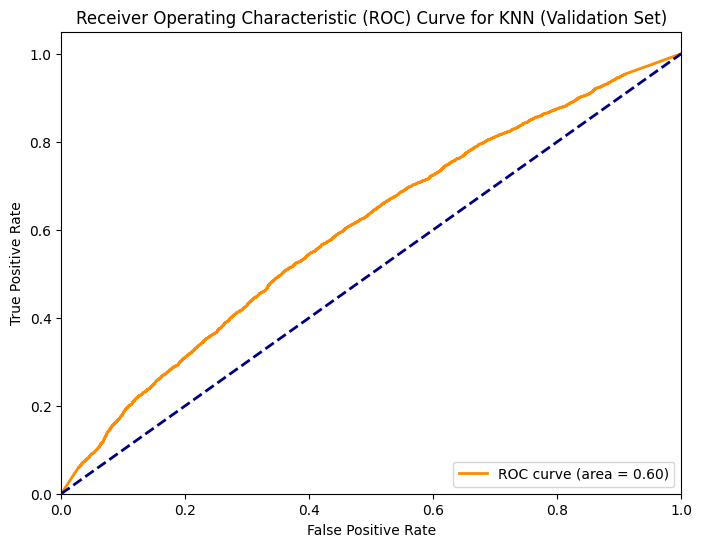

KNN Validation ROC AUC: 0.5978


In [38]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

if y_pred_proba_knn_leakage_free_val.shape[1] == 2:
    y_scores_knn_leakage_free_val = y_pred_proba_knn_leakage_free_val[:, 1]
else:
    y_scores_knn_leakage_free_val = y_pred_proba_knn_leakage_free_val.ravel() # For single column probability outputs

fpr_knn_leakage_free_val, tpr_knn_leakage_free_val, thresholds_knn_leakage_free_val = roc_curve(y_knn_val_raw, y_scores_knn_leakage_free_val)
roc_auc_knn_leakage_free_val = auc(fpr_knn_leakage_free_val, tpr_knn_leakage_free_val)

plt.figure(figsize=(8, 6))
plt.plot(fpr_knn_leakage_free_val, tpr_knn_leakage_free_val, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_knn_leakage_free_val:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for KNN (Validation Set)')
plt.legend(loc='lower right')
plt.show()

print(f"KNN Validation ROC AUC: {roc_auc_knn_leakage_free_val:.4f}")

###Testing


In [39]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score, roc_auc_score

#  predictions
y_pred_knn_leakage_free_test = knn_model_leakage_free.predict(X_knn_test_pca_df)
y_pred_proba_knn_leakage_free_test = knn_model_leakage_free.predict_proba(X_knn_test_pca_df)

print("\n--- KNN Test Set Evaluation ---")

# Accuracy
accuracy_knn_leakage_free_test = accuracy_score(y_knn_test_raw, y_pred_knn_leakage_free_test)
print(f"KNN  Test Accuracy Score: {accuracy_knn_leakage_free_test:.4f}")

# Confusion Matrix
conf_matrix_knn_leakage_free_test = confusion_matrix(y_knn_test_raw, y_pred_knn_leakage_free_test)
print("\nKNN  Test Confusion Matrix:")
print(conf_matrix_knn_leakage_free_test)

# Classification Report
class_report_knn_leakage_free_test = classification_report(y_knn_test_raw, y_pred_knn_leakage_free_test, target_names=['NO (0)', 'Readmitted (1)'], digits=4)
print("\nKNN  Test Classification Report:")
print(class_report_knn_leakage_free_test)

# Individual precision, recall, f1 (weighted)
precision_knn_leakage_free_test = precision_score(y_knn_test_raw, y_pred_knn_leakage_free_test, average='weighted', zero_division=0)
recall_knn_leakage_free_test = recall_score(y_knn_test_raw, y_pred_knn_leakage_free_test, average='weighted', zero_division=0)
f1_knn_leakage_free_test = f1_score(y_knn_test_raw, y_pred_knn_leakage_free_test, average='weighted', zero_division=0)
print(f"\nKNN  Test Precision Score (weighted): {precision_knn_leakage_free_test:.4f}")
print(f"KNN  Test Recall Score (weighted): {recall_knn_leakage_free_test:.4f}")
print(f"KNN  Test F1 Score (weighted): {f1_knn_leakage_free_test:.4f}")

# ROC AUC
roc_auc_knn_leakage_free_test = roc_auc_score(y_knn_test_raw, y_pred_proba_knn_leakage_free_test[:, 1])
print(f"KNN Test ROC AUC: {roc_auc_knn_leakage_free_test:.4f}")



--- KNN Test Set Evaluation ---
KNN  Test Accuracy Score: 0.5821

KNN  Test Confusion Matrix:
[[4260 2603]
 [2738 3181]]

KNN  Test Classification Report:
                precision    recall  f1-score   support

        NO (0)     0.6087    0.6207    0.6147      6863
Readmitted (1)     0.5500    0.5374    0.5436      5919

      accuracy                         0.5821     12782
     macro avg     0.5794    0.5791    0.5791     12782
  weighted avg     0.5815    0.5821    0.5818     12782


KNN  Test Precision Score (weighted): 0.5815
KNN  Test Recall Score (weighted): 0.5821
KNN  Test F1 Score (weighted): 0.5818
KNN Test ROC AUC: 0.6075


##Comparison of all Models For Diabetes

In [40]:
model_performance_metrics = {}
print(" empty dictionary for 'model_performance_metrics'.")

 empty dictionary for 'model_performance_metrics'.


In [41]:
import pandas as pd

# All models (Validation)
for model_name in ['Logistic Regression', 'Decision Tree', 'Random Forest']:
    metrics = validation_results[model_name]
    model_performance_metrics[f'{model_name} (Validation)'] = {
        'Accuracy': metrics['accuracy'],
        'Precision': metrics['precision'],
        'Recall': metrics['recall'],
        'F1-weighted': metrics['f1_weighted'],
        'ROC AUC': metrics['roc_auc']
    }

# 3. Random Forest (Test)
model_performance_metrics['Random Forest (Test)'] = {
    'Accuracy': accuracy_test,
    'Precision': precision_test,
    'Recall': recall_test,
    'F1-weighted': f1_test,
    'ROC AUC': roc_auc_test
}

# 4. KNN (Validation)
model_performance_metrics['KNN (Validation)'] = {
    'Accuracy': accuracy_knn_leakage_free_val,
    'Precision': precision_knn_leakage_free_val,
    'Recall': recall_knn_leakage_free_val,
    'F1-weighted': f1_knn_leakage_free_val,
    'ROC AUC': roc_auc_knn_leakage_free_val
}

# KNN (Test)
model_performance_metrics['KNN (Test)'] = {
    'Accuracy': accuracy_knn_leakage_free_test,
    'Precision': precision_knn_leakage_free_test,
    'Recall': recall_knn_leakage_free_test,
    'F1-weighted': f1_knn_leakage_free_test,
    'ROC AUC': roc_auc_knn_leakage_free_test

}


performance_df = pd.DataFrame.from_dict(model_performance_metrics, orient='index')
print("Model Performance Metrics:")
display(performance_df)


Model Performance Metrics:


,Accuracy,Precision,Recall,F1-weighted,ROC AUC
Logistic Regression (Validation),0.601982,0.607491,0.601982,0.602218,0.649267
Decision Tree (Validation),0.582497,0.585776,0.582497,0.583048,0.621920
Random Forest (Validation),0.630711,0.629246,0.630711,0.628089,0.676639
Random Forest (Test),0.637295,0.636068,0.637295,0.634014,0.684251
KNN (Validation),0.576011,0.575118,0.576011,0.575431,0.597830
KNN (Test),0.582147,0.581526,0.582147,0.581772,0.607539


### Heatmap of Model Performance Metrics

/tmp/ipython-input-1101155210.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  (performance_df.index.str.contains('(Test)') == False)


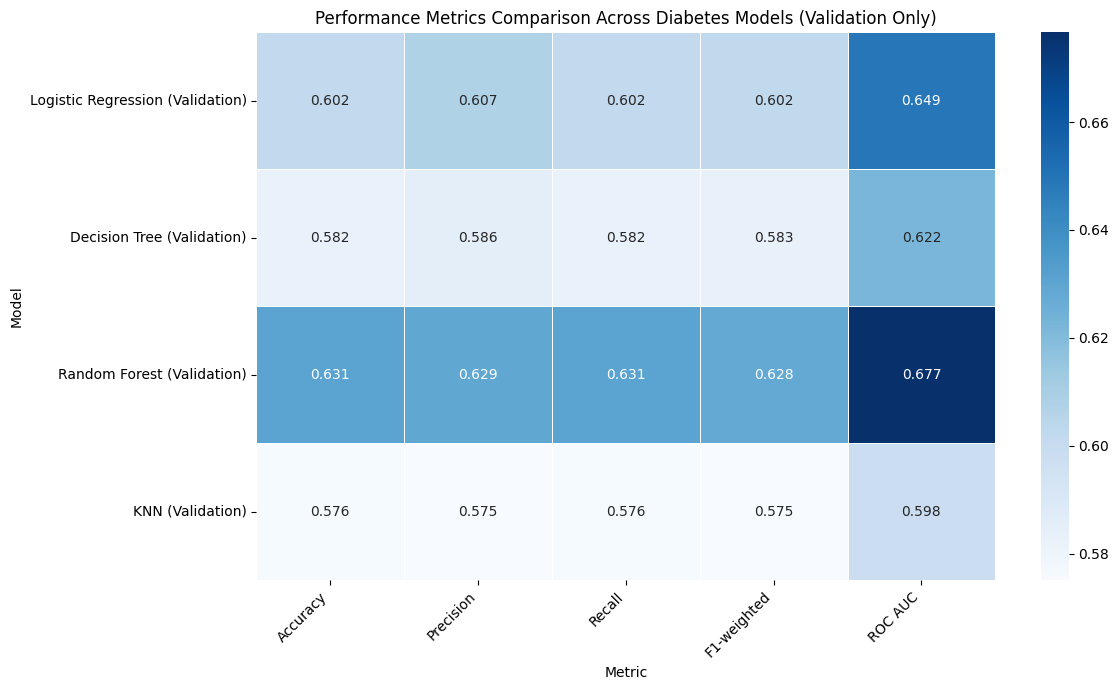

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

diabetes_model_metrics_df = performance_df[
    (performance_df.index.str.contains('Hospital') == False) &
    (performance_df.index.str.contains('(Test)') == False)
].copy()


diabetes_model_metrics_df = diabetes_model_metrics_df.apply(pd.to_numeric, errors='coerce')


plt.figure(figsize=(12, 7))
sns.heatmap(diabetes_model_metrics_df, annot=True, cmap='Blues', fmt=".3f", linewidths=.5)
plt.title('Performance Metrics Comparison Across Diabetes Models (Validation Only)')
plt.ylabel('Model')
plt.xlabel('Metric')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

###Roc Comparison

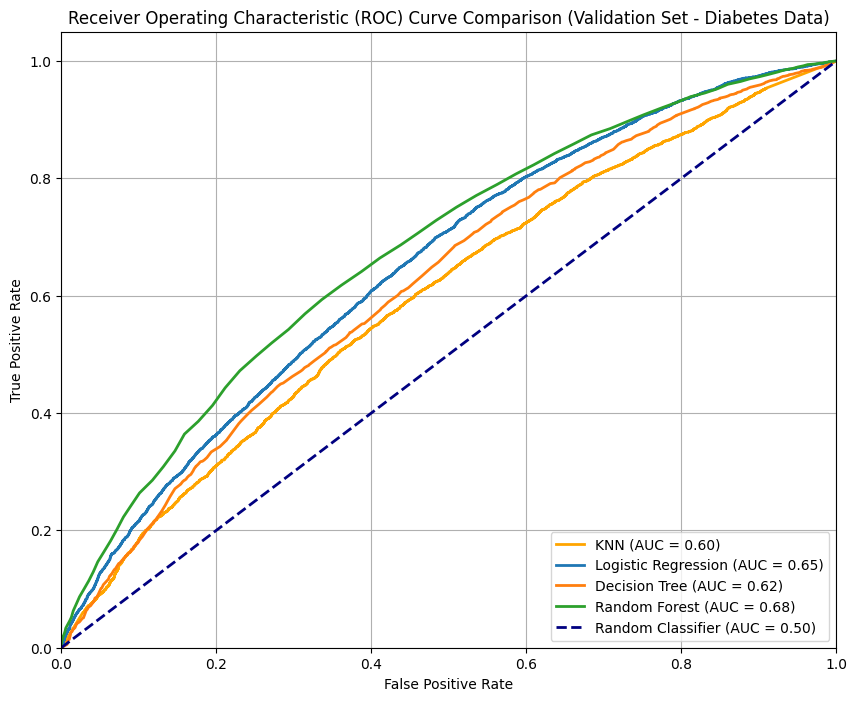

In [43]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

#KNN
plt.plot(fpr_knn_leakage_free_val, tpr_knn_leakage_free_val, color='orange', lw=2, label=f'KNN (AUC = {roc_auc_knn_leakage_free_val:.2f})')

#other models
for model_name, metrics in validation_results.items():
    if model_name != 'KNN':
        best_model = results[model_name]['best_estimator']


        if hasattr(best_model, 'predict_proba'):

            y_pred_proba_val = best_model.predict_proba(X_val)[:, 1]
            fpr, tpr, _ = roc_curve(y_val, y_pred_proba_val)
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {roc_auc:.2f})')

# random classifier
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier (AUC = 0.50)')


plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison (Validation Set - Diabetes Data)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

#Data Set- Medicaid Hospital Penalties

In [44]:
hospital_data_path = my_drive_path + 'Actual Hospital Data.csv'
hospital_data_df = pd.read_csv(hospital_data_path)

print("First 5 rows of Actual Hospital Data.csv:")
display(hospital_data_df.head())

print("\nDataFrame Information:")
display(hospital_data_df.info())

print("\nDescriptive Statistics:")
display(hospital_data_df.describe())

First 5 rows of Actual Hospital Data.csv:


,Provider_ID,Hospital_Name,NPI,State_Abbreviation,State,State_FIPS_Code,Measure_Name,Measure_Description,Number_of_Discharges,Footnote_Code,...,Expected_Readmission_Rate,Number_of_Readmissions,Start_Date,End_Date,ICD10_Code,ICD10_Description,HCPCS_Code,HCPCS_Description,Latitude,Longitude
0,20001,PROVIDENCE ALASKA MEDICAL CENTER,NaN,AK,Alaska,2,READM-30-AMI-HRRP,Acute Myocardial Infarction (AMI) 30-Day Readm...,393.0,NaN,...,14.0941,50,2017-07-01,2019-12-01,"I21.3, I21.4",ST elevation (STEMI) myocardial infarction of ...,C9606,Percutaneous transluminal revascularization of...,NaN,NaN
1,20001,PROVIDENCE ALASKA MEDICAL CENTER,NaN,AK,Alaska,2,READM-30-CABG-HRRP,Rate of readmission for CABG,NaN,NaN,...,11.7634,Too Few to Report,2017-07-01,2019-12-01,"T82.21, T82.211, T82.212, T82.213, T82.218",Mechanical complication of coronary artery byp...,C9604,Percutaneous transluminal revascularization of...,NaN,NaN
2,20001,PROVIDENCE ALASKA MEDICAL CENTER,NaN,AK,Alaska,2,READM-30-COPD-HRRP,Rate of readmission for chronic obstructive pu...,216.0,NaN,...,18.6011,40,2017-07-01,2019-12-01,"J44.0, J44.1, J44.9",Chronic obstructive pulmon disease w acute low...,G9681,This code is for onsite acute care treatment o...,NaN,NaN
3,20001,PROVIDENCE ALASKA MEDICAL CENTER,NaN,AK,Alaska,2,READM-30-HF-HRRP,Heart failure (HF) 30-Day Readmission Rate,418.0,NaN,...,21.3239,86,2017-07-01,2019-12-01,I50.9,"Heart failure, unspecified",G9680,This code is for onsite acute care treatment o...,NaN,NaN
4,20001,PROVIDENCE ALASKA MEDICAL CENTER,NaN,AK,Alaska,2,READM-30-HIP-KNEE-HRRP,Rate of readmission after hip/knee replacement,277.0,NaN,...,3.3971,11,2017-07-01,2019-12-01,S78.119D,Complete traumatic amputation at level between...,L5850,"Addition, endoskeletal system, above knee or h...",NaN,NaN



DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19020 entries, 0 to 19019
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Provider_ID                 19020 non-null  int64  
 1   Hospital_Name               19020 non-null  object 
 2   NPI                         17424 non-null  float64
 3   State_Abbreviation          19020 non-null  object 
 4   State                       19020 non-null  object 
 5   State_FIPS_Code             19020 non-null  int64  
 6   Measure_Name                19020 non-null  object 
 7   Measure_Description         19020 non-null  object 
 8   Number_of_Discharges        10120 non-null  float64
 9   Footnote_Code               5641 non-null   float64
 10  Footnote_Description        0 non-null      float64
 11  Excess_Readmission_Ratio    13379 non-null  float64
 12  Predicted_Readmission_Rate  13379 non-null  float64
 13  Expecte

None


Descriptive Statistics:


,Provider_ID,NPI,State_FIPS_Code,Number_of_Discharges,Footnote_Code,Footnote_Description,Excess_Readmission_Ratio,Predicted_Readmission_Rate,Expected_Readmission_Rate,Latitude,Longitude
count,19020.000000,1.742400e+04,19020.000000,10120.000000,5641.000000,0.0,13379.000000,13379.000000,13379.000000,0.0,0.0
mean,261964.582650,1.502532e+09,28.242271,328.018083,3.539266,NaN,1.002025,15.517469,15.480933,NaN,NaN
std,163169.170206,2.888511e+08,15.993380,298.598890,2.009355,NaN,0.084050,6.066150,5.917159,NaN,NaN
min,10001.000000,1.003233e+09,1.000000,28.000000,1.000000,NaN,0.632200,2.227300,2.466100,NaN,NaN
25%,110104.000000,1.245428e+09,13.000000,137.000000,1.000000,NaN,0.955400,13.284750,13.539350,NaN,NaN
50%,250064.000000,1.508844e+09,28.000000,239.000000,5.000000,NaN,0.998200,16.852500,16.762300,NaN,NaN
75%,390115.000000,1.750348e+09,42.000000,418.000000,5.000000,NaN,1.044100,19.805650,19.910300,NaN,NaN
max,670300.000000,1.992910e+09,56.000000,7377.000000,7.000000,NaN,1.825400,33.191400,28.597700,NaN,NaN


In [45]:
missing_counts = hospital_data_df.isnull().sum()
missing_percentages = (hospital_data_df.isnull().sum() / len(hospital_data_df)) * 100

missing_info_hospital = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percent': missing_percentages
})


missing_info_hospital = missing_info_hospital[missing_info_hospital['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

print("Missing Values Information for Actual Hospital Data.csv:")
display(missing_info_hospital)


Missing Values Information for Actual Hospital Data.csv:


,Missing Count,Missing Percent
Longitude,19020,100.000000
Footnote_Description,19020,100.000000
Latitude,19020,100.000000
Footnote_Code,13379,70.341746
Number_of_Discharges,8900,46.792850
Predicted_Readmission_Rate,5641,29.658254
Number_of_Readmissions,5641,29.658254
Excess_Readmission_Ratio,5641,29.658254
Expected_Readmission_Rate,5641,29.658254
NPI,1596,8.391167


##Cleaning

In [46]:
hospital_data_df_cleaned = hospital_data_df.drop(columns=['Longitude', 'Footnote_Description', 'Latitude', 'State_Abbreviation', 'Footnote_Code', 'ICD10_Description', 'HCPCS_Description', 'Start_Date', 'End_Date', 'Measure_Description', 'State_FIPS_Code'])

print("Columns dropped: Longitude, Footnote_Description, Latitude,State_Abbreviation")
print(f"New shape of DataFrame: {hospital_data_df_cleaned.shape}")

#check
missing_counts_cleaned = hospital_data_df_cleaned.isnull().sum()
missing_percentages_cleaned = (hospital_data_df_cleaned.isnull().sum() / len(hospital_data_df_cleaned)) * 100

missing_info_hospital_cleaned = pd.DataFrame({
    'Missing Count': missing_counts_cleaned,
    'Missing Percent': missing_percentages_cleaned
})

missing_info_hospital_cleaned = missing_info_hospital_cleaned[missing_info_hospital_cleaned['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

print("\nMissing Values Information after dropping 100% missing and redundant columns:")
display(missing_info_hospital_cleaned)

Columns dropped: Longitude, Footnote_Description, Latitude,State_Abbreviation
New shape of DataFrame: (19020, 12)

Missing Values Information after dropping 100% missing and redundant columns:


,Missing Count,Missing Percent
Number_of_Discharges,8900,46.792850
Excess_Readmission_Ratio,5641,29.658254
Expected_Readmission_Rate,5641,29.658254
Predicted_Readmission_Rate,5641,29.658254
Number_of_Readmissions,5641,29.658254
NPI,1596,8.391167


In [47]:
numerical_cols_to_impute = [
    'NPI',
    'Number_of_Discharges',
    'Excess_Readmission_Ratio',
    'Predicted_Readmission_Rate',
    'Expected_Readmission_Rate'
]

for col in numerical_cols_to_impute:
    if hospital_data_df_cleaned[col].isnull().any():
        median_val = hospital_data_df_cleaned[col].median()
        hospital_data_df_cleaned[col].fillna(median_val, inplace=True)
        print(f"Imputed column '{col}' with median: {median_val}")

# Number_of_Readmissions = mode
if hospital_data_df_cleaned['Number_of_Readmissions'].isnull().any():
    mode_val = hospital_data_df_cleaned['Number_of_Readmissions'].mode()[0]
    hospital_data_df_cleaned['Number_of_Readmissions'].fillna(mode_val, inplace=True)
    print(f"Imputed column 'Number_of_Readmissions' with mode: {mode_val}")

print("\nMissing Values Information after imputation:")
missing_counts_final = hospital_data_df_cleaned.isnull().sum()
missing_percentages_final = (hospital_data_df_cleaned.isnull().sum() / len(hospital_data_df_cleaned)) * 100

missing_info_hospital_final = pd.DataFrame({
    'Missing Count': missing_counts_final,
    'Missing Percent': missing_percentages_final
})

missing_info_hospital_final = missing_info_hospital_final[missing_info_hospital_final['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)
display(missing_info_hospital_final)

print("\nUpdated DataFrame Info after imputation:")
display(hospital_data_df_cleaned.info())


Imputed column 'NPI' with median: 1508844444.0
Imputed column 'Number_of_Discharges' with median: 239.0
Imputed column 'Excess_Readmission_Ratio' with median: 0.9982
Imputed column 'Predicted_Readmission_Rate' with median: 16.8525
Imputed column 'Expected_Readmission_Rate' with median: 16.7623
Imputed column 'Number_of_Readmissions' with mode: Too Few to Report

Missing Values Information after imputation:


/tmp/ipython-input-646428365.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  hospital_data_df_cleaned[col].fillna(median_val, inplace=True)
/tmp/ipython-input-646428365.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=

,Missing Count,Missing Percent



Updated DataFrame Info after imputation:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19020 entries, 0 to 19019
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Provider_ID                 19020 non-null  int64  
 1   Hospital_Name               19020 non-null  object 
 2   NPI                         19020 non-null  float64
 3   State                       19020 non-null  object 
 4   Measure_Name                19020 non-null  object 
 5   Number_of_Discharges        19020 non-null  float64
 6   Excess_Readmission_Ratio    19020 non-null  float64
 7   Predicted_Readmission_Rate  19020 non-null  float64
 8   Expected_Readmission_Rate   19020 non-null  float64
 9   Number_of_Readmissions      19020 non-null  object 
 10  ICD10_Code                  19020 non-null  object 
 11  HCPCS_Code                  19020 non-null  object 
dtypes: float64(5), int64(1), object(6)
memory usag

None

##EDA

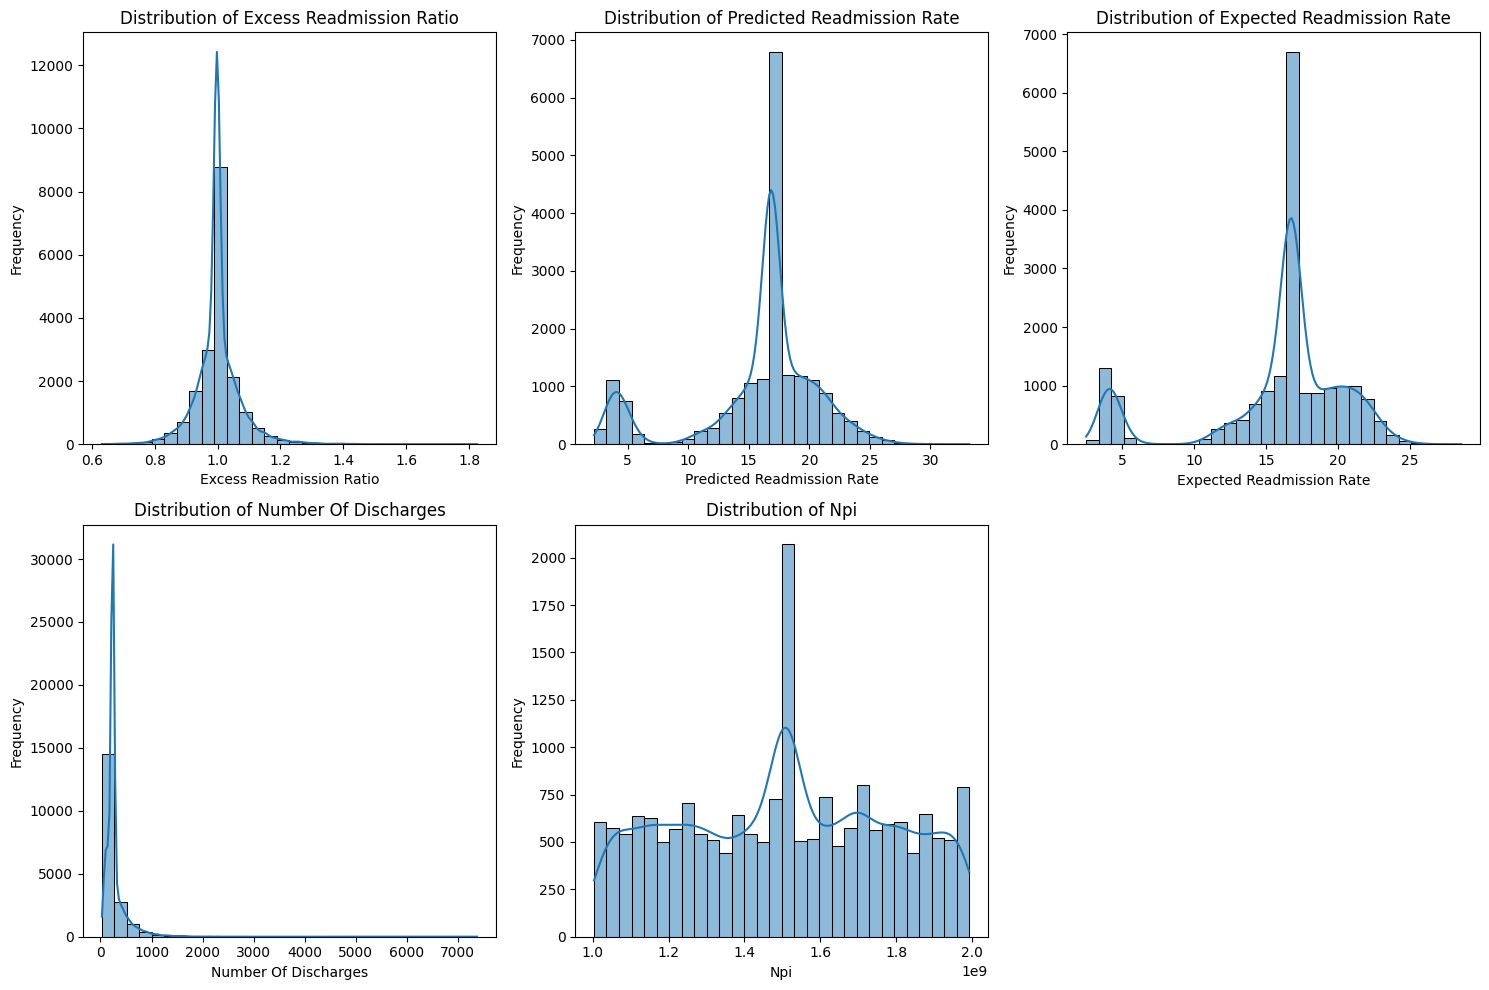

Histograms for numerical features in hospital_data_df_cleaned generated successfully.


In [48]:
import seaborn as sns
numerical_features_hospital = ['Excess_Readmission_Ratio', 'Predicted_Readmission_Rate', 'Expected_Readmission_Rate', 'Number_of_Discharges', 'NPI']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features_hospital):
    plt.subplot(2, 3, i + 1)
    sns.histplot(hospital_data_df_cleaned[feature], kde=True, bins=30)
    plt.title(f'Distribution of {feature.replace("_", " ").title()}')
    plt.xlabel(feature.replace("_", " ").title())
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

print("Histograms for numerical features in hospital_data_df_cleaned generated successfully.")

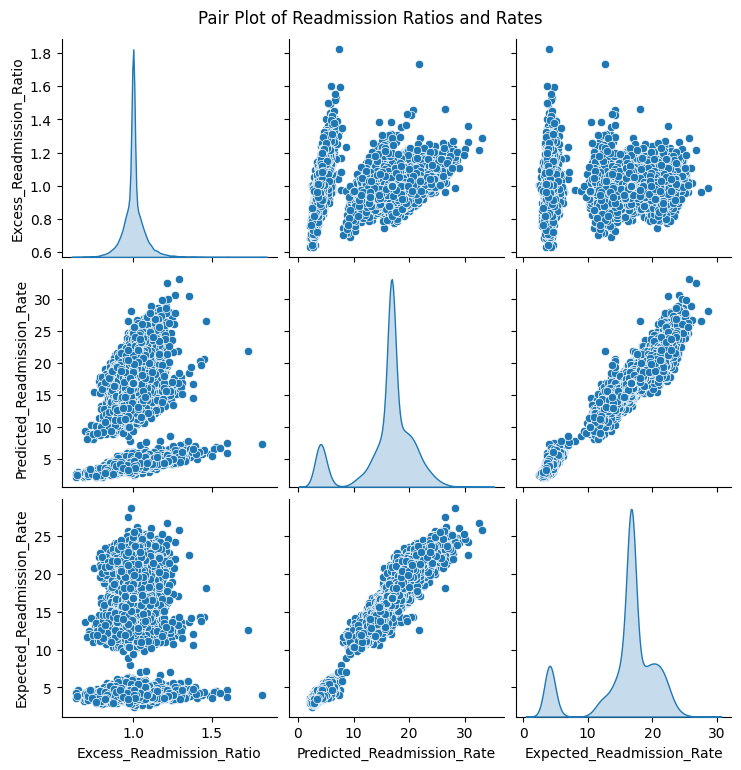

Pair plots for readmission ratios and rates generated successfully.


In [49]:
selected_numerical_features = ['Excess_Readmission_Ratio', 'Predicted_Readmission_Rate', 'Expected_Readmission_Rate']
sns.pairplot(hospital_data_df_cleaned[selected_numerical_features], diag_kind='kde')
plt.suptitle('Pair Plot of Readmission Ratios and Rates', y=1.02)
plt.show()

print("Pair plots for readmission ratios and rates generated successfully.")

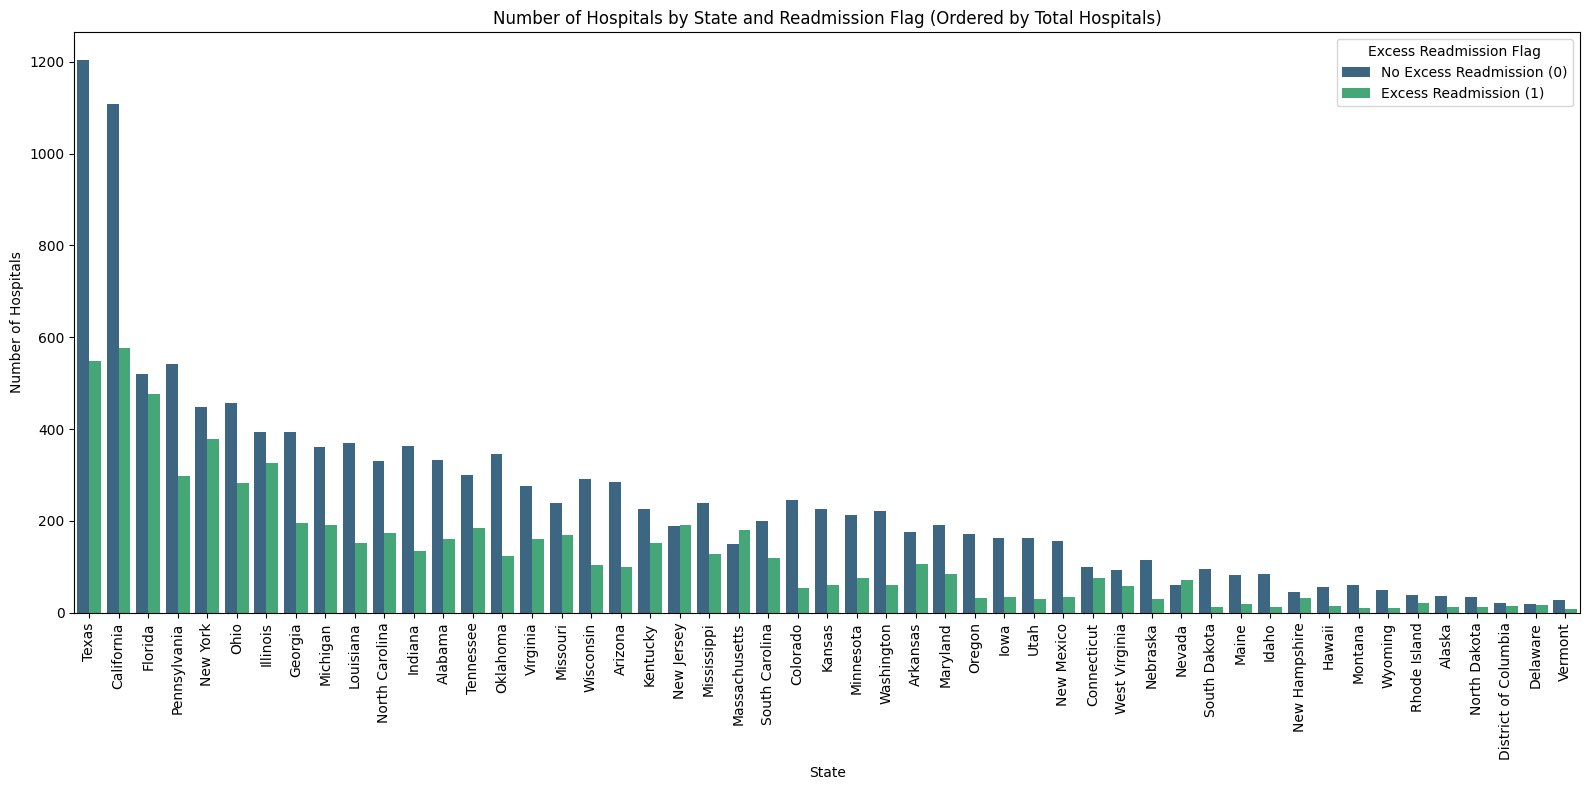

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'excess_readmission_flag' exists
hospital_data_df_cleaned['excess_readmission_flag'] = (hospital_data_df_cleaned['Excess_Readmission_Ratio'] > 1.0).astype(int)

# Calculate total hospitals per state to get the order
state_order = hospital_data_df_cleaned['State'].value_counts().index

plt.figure(figsize=(16, 8))
sns.countplot(data=hospital_data_df_cleaned, x='State', hue='excess_readmission_flag', palette='viridis', order=state_order)
plt.title('Number of Hospitals by State and Readmission Flag (Ordered by Total Hospitals)')
plt.xlabel('State')
plt.ylabel('Number of Hospitals')
plt.xticks(rotation=90) # Rotate state names for better readability
plt.legend(title='Excess Readmission Flag', labels=['No Excess Readmission (0)', 'Excess Readmission (1)'], loc='upper right')
plt.tight_layout()
plt.show()

##Preprocessing

Categorical Values

In [51]:

# Number_of_Readmissions
hospital_data_df_cleaned['Number_of_Readmissions'] = hospital_data_df_cleaned['Number_of_Readmissions'].replace('Too Few to Report', np.nan)
hospital_data_df_cleaned['Number_of_Readmissions'] = pd.to_numeric(hospital_data_df_cleaned['Number_of_Readmissions'])


median_readmissions = hospital_data_df_cleaned['Number_of_Readmissions'].median()
hospital_data_df_cleaned['Number_of_Readmissions'] = hospital_data_df_cleaned['Number_of_Readmissions'].fillna(median_readmissions)


categorical_features_for_encoding = [
     'State', 'Measure_Name',
    'ICD10_Code', 'HCPCS_Code'
]

hospital_data_df_encoded = pd.get_dummies(hospital_data_df_cleaned, columns=categorical_features_for_encoding, drop_first=True)

# Drop original date columns
hospital_data_df_encoded = hospital_data_df_encoded.drop(columns=[ 'Hospital_Name'])

print("\nShape of DataFrame")
print(hospital_data_df_encoded.shape)

print("\nFirst 5 rows of the encoded DataFrame:")
display(hospital_data_df_encoded.head())


Shape of DataFrame
(19020, 73)

First 5 rows of the encoded DataFrame:


,Provider_ID,NPI,Number_of_Discharges,Excess_Readmission_Ratio,Predicted_Readmission_Rate,Expected_Readmission_Rate,Number_of_Readmissions,excess_readmission_flag,State_Alaska,State_Arizona,...,ICD10_Code_I50.9,ICD10_Code_J18.9,"ICD10_Code_J44.0, J44.1, J44.9",ICD10_Code_S78.119D,"ICD10_Code_T82.21, T82.211, T82.212, T82.213, T82.218",HCPCS_Code_C9606,HCPCS_Code_G9679,HCPCS_Code_G9680,HCPCS_Code_G9681,HCPCS_Code_L5850
0,20001,1.508844e+09,393.0,0.9528,13.4284,14.0941,50.0,0,True,False,...,False,False,False,False,False,True,False,False,False,False
1,20001,1.508844e+09,239.0,0.9334,10.9799,11.7634,36.0,0,True,False,...,False,False,False,False,True,False,False,False,False,False
2,20001,1.508844e+09,216.0,0.9986,18.5753,18.6011,40.0,0,True,False,...,False,False,True,False,False,False,False,False,True,False
3,20001,1.508844e+09,418.0,0.9798,20.8934,21.3239,86.0,0,True,False,...,True,False,False,False,False,False,False,True,False,False
4,20001,1.508844e+09,277.0,1.0598,3.6002,3.3971,11.0,1,True,False,...,False,False,False,True,False,False,False,False,False,True


## Standardize Numerical Features




In [52]:
from sklearn.preprocessing import StandardScaler

#  numerical columns
numerical_cols_hospital = hospital_data_df_encoded.select_dtypes(include=np.number).columns


scaler_hospital = StandardScaler()

hospital_data_scaled_array = scaler_hospital.fit_transform(hospital_data_df_encoded[numerical_cols_hospital])

hospital_data_scaled = pd.DataFrame(hospital_data_scaled_array, columns=numerical_cols_hospital, index=hospital_data_df_encoded.index)

print("First 5 rows of the scaled hospital data:")
display(hospital_data_scaled.head())
print(f"Shape of hospital_data_scaled: {hospital_data_scaled.shape}")

First 5 rows of the scaled hospital data:


,Provider_ID,NPI,Number_of_Discharges,Excess_Readmission_Ratio,Predicted_Readmission_Rate,Expected_Readmission_Rate,Number_of_Readmissions,excess_readmission_flag
0,-1.482939,0.020917,0.479737,-0.682023,-0.484985,-0.353590,0.121303,-0.721376
1,-1.482939,0.020917,-0.213083,-0.957156,-0.962844,-0.820017,-0.239949,-0.721376
2,-1.482939,0.020917,-0.316556,-0.032483,0.519503,0.548364,-0.136734,-0.721376
3,-1.482939,0.020917,0.592208,-0.299106,0.971912,1.093259,1.050238,-0.721376
4,-1.482939,0.020917,-0.042127,0.835462,-2.403094,-2.494305,-0.885042,1.386239


Shape of hospital_data_scaled: (19020, 8)


## PCA


In [53]:
from sklearn.decomposition import PCA

pca_hospital = PCA()

pca_hospital.fit(hospital_data_scaled)
cum_explained_variance_hospital = np.cumsum(pca_hospital.explained_variance_ratio_)
variance_threshold_90 = 0.90
num_components_90_hospital = np.argmax(cum_explained_variance_hospital >= variance_threshold_90) + 1

print(f"Number of components to explain {variance_threshold_90*100:.0f}% of variance in hospital data: {num_components_90_hospital}")

Number of components to explain 90% of variance in hospital data: 5


In [54]:
from sklearn.decomposition import PCA


pca_hospital = PCA(n_components=num_components_90_hospital)

hospital_data_pca_array = pca_hospital.fit_transform(hospital_data_scaled)
hospital_data_pca = pd.DataFrame(hospital_data_pca_array, columns=[f'PC{i+1}' for i in range(num_components_90_hospital)], index=hospital_data_scaled.index)

print(f"Shape of PCA-transformed hospital data: {hospital_data_pca.shape}")
print("First 5 rows of hospital_data_pca:")
display(hospital_data_pca.head())

Shape of PCA-transformed hospital data: (19020, 5)
First 5 rows of hospital_data_pca:


,PC1,PC2,PC3,PC4,PC5
0,-0.578913,0.530050,-0.867476,1.121416,-1.076098
1,-1.483794,0.203559,-0.687459,1.116038,-1.117845
2,0.389973,-0.772104,-0.446506,1.036683,-1.100172
3,1.618457,0.066389,-1.194427,1.080346,-1.034609
4,-2.701424,1.584596,2.373645,1.015657,-1.007899


In [55]:
pca_loadings_hospital = pd.DataFrame(pca_hospital.components_, columns=hospital_data_scaled.columns, index=[f'PC{i+1}' for i in range(num_components_90_hospital)])

print("PCA Loadings for Hospital Data (Contribution of original features to each Principal Component):")
display(pca_loadings_hospital)

print("\nTop features contributing to each Principal Component (absolute value) for Hospital Data:")
for i in range(num_components_90_hospital):
    pc_name = f'PC{i+1}'
    top_features = pca_loadings_hospital.loc[pc_name].abs().sort_values(ascending=False).head(5)
    print(f"\n{pc_name}:\n{top_features}")

PCA Loadings for Hospital Data (Contribution of original features to each Principal Component):


,Provider_ID,NPI,Number_of_Discharges,Excess_Readmission_Ratio,Predicted_Readmission_Rate,Expected_Readmission_Rate,Number_of_Readmissions,excess_readmission_flag
PC1,-0.038724,-0.008927,0.200221,0.215310,0.592925,0.563062,0.445573,0.211754
PC2,-0.013493,-0.058974,0.666461,0.063392,-0.346801,-0.368357,0.511681,0.174287
PC3,-0.057561,0.022409,-0.250979,0.667394,-0.081269,-0.193139,-0.168403,0.644602
PC4,-0.689291,0.721225,0.035284,-0.035071,-0.017822,-0.013439,0.014855,-0.038969
PC5,0.720968,0.689754,0.034397,0.023618,0.000218,-0.003370,0.035670,0.037678



Top features contributing to each Principal Component (absolute value) for Hospital Data:

PC1:
Predicted_Readmission_Rate    0.592925
Expected_Readmission_Rate     0.563062
Number_of_Readmissions        0.445573
Excess_Readmission_Ratio      0.215310
excess_readmission_flag       0.211754
Name: PC1, dtype: float64

PC2:
Number_of_Discharges          0.666461
Number_of_Readmissions        0.511681
Expected_Readmission_Rate     0.368357
Predicted_Readmission_Rate    0.346801
excess_readmission_flag       0.174287
Name: PC2, dtype: float64

PC3:
Excess_Readmission_Ratio     0.667394
excess_readmission_flag      0.644602
Number_of_Discharges         0.250979
Expected_Readmission_Rate    0.193139
Number_of_Readmissions       0.168403
Name: PC3, dtype: float64

PC4:
NPI                         0.721225
Provider_ID                 0.689291
excess_readmission_flag     0.038969
Number_of_Discharges        0.035284
Excess_Readmission_Ratio    0.035071
Name: PC4, dtype: float64

PC5:
Provider_I

##Target Variable for Hospital Data




In [56]:
hospital_data_df_cleaned['excess_readmission_flag'] = (hospital_data_df_cleaned['Excess_Readmission_Ratio'] > 1.0).astype(int)

print("Value counts for 'excess_readmission_flag':")
display(hospital_data_df_cleaned['excess_readmission_flag'].value_counts())

print("First 5 rows of hospital_data_df_cleaned with new flag:")
display(hospital_data_df_cleaned[['Excess_Readmission_Ratio', 'excess_readmission_flag']].head())

Value counts for 'excess_readmission_flag':


,count
excess_readmission_flag,
0,12510
1,6510


First 5 rows of hospital_data_df_cleaned with new flag:


,Excess_Readmission_Ratio,excess_readmission_flag
0,0.9528,0
1,0.9334,0
2,0.9986,0
3,0.9798,0
4,1.0598,1


## Split Hospital Data for Classification Post PCA



In [57]:
from sklearn.model_selection import train_test_split

X_hospital = hospital_data_pca
y_hospital = hospital_data_df_cleaned['excess_readmission_flag']

# Split hospital data into training (70%) and a temporary set (30%)
X_train_hospital_pca, X_temp_hospital_pca, y_train_hospital, y_temp_hospital = train_test_split(
    X_hospital, y_hospital,
    test_size=0.3,  # 30% for temp (which will be split into val and test)
    random_state=42,
    stratify=y_hospital
)

# Split the temporary set into validation (15% of total) and test (15% of total)
X_val_hospital_pca, X_test_hospital_pca, y_val_hospital, y_test_hospital = train_test_split(
    X_temp_hospital_pca, y_temp_hospital,
    test_size=0.5,  # 50% of the temporary set (0.5 * 0.3 = 0.15 of total)
    random_state=42,
    stratify=y_temp_hospital
)

print(f"Shape of X_train_hospital_pca: {X_train_hospital_pca.shape}")
print(f"Shape of y_train_hospital: {y_train_hospital.shape}")
print(f"Shape of X_val_hospital_pca: {X_val_hospital_pca.shape}")
print(f"Shape of y_val_hospital: {y_val_hospital.shape}")
print(f"Shape of X_test_hospital_pca: {X_test_hospital_pca.shape}")
print(f"Shape of y_test_hospital: {y_test_hospital.shape}")

Shape of X_train_hospital_pca: (13314, 5)
Shape of y_train_hospital: (13314,)
Shape of X_val_hospital_pca: (2853, 5)
Shape of y_val_hospital: (2853,)
Shape of X_test_hospital_pca: (2853, 5)
Shape of y_test_hospital: (2853,)


Class Weights for Hospital Data



In [58]:
classes_hospital = np.unique(y_train_hospital)
class_weights_hospital = compute_class_weight(class_weight='balanced', classes=classes_hospital, y=y_train_hospital)
class_weights_dict_hospital = dict(zip(classes_hospital, class_weights_hospital))

print("Computed class weights for hospital training set:")
display(class_weights_dict_hospital)

Computed class weights for hospital training set:


{np.int64(0): np.float64(0.7601918465227818),
 np.int64(1): np.float64(1.4608294930875576)}

##  Classification Model Training


In [59]:
from sklearn.ensemble import RandomForestClassifier

rf_model_hospital_pca = RandomForestClassifier(
    random_state=42,
    class_weight=class_weights_dict_hospital
)

rf_model_hospital_pca.fit(X_train_hospital_pca, y_train_hospital)


RandomForestClassifier(class_weight={np.int64(0): np.float64(0.7601918465227818),
                                     np.int64(1): np.float64(1.4608294930875576)},
                       random_state=42)

Prediction


In [60]:
y_pred_rf_hospital_pca = rf_model_hospital_pca.predict(X_val_hospital_pca)
y_pred_proba_rf_hospital_pca = rf_model_hospital_pca.predict_proba(X_val_hospital_pca)

print("First 5 predicted class labels (y_pred_rf_hospital_pca):")
display(y_pred_rf_hospital_pca[:5])

print("\nFirst 5 predicted probabilities (y_pred_proba_rf_hospital_pca):")
display(y_pred_proba_rf_hospital_pca[:5])

print("Predictions for X_val_hospital_pca generated successfully for Random Forest model.")

First 5 predicted class labels (y_pred_rf_hospital_pca):


array([0, 1, 0, 1, 1])


First 5 predicted probabilities (y_pred_proba_rf_hospital_pca):


array([[0.99, 0.01],
       [0.  , 1.  ],
       [0.99, 0.01],
       [0.  , 1.  ],
       [0.  , 1.  ]])

Predictions for X_val_hospital_pca generated successfully for Random Forest model.


Performance



In [61]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy_rf_hospital_pca = accuracy_score(y_val_hospital, y_pred_rf_hospital_pca)
print(f"Random Forest (Hospital PCA) Accuracy Score: {accuracy_rf_hospital_pca:.4f}")

conf_matrix_rf_hospital_pca = confusion_matrix(y_val_hospital, y_pred_rf_hospital_pca)
print("\nRandom Forest (Hospital PCA) Confusion Matrix:")
print(conf_matrix_rf_hospital_pca)

class_report_rf_hospital_pca = classification_report(y_val_hospital, y_pred_rf_hospital_pca, target_names=['No Excess (0)', 'Excess (1)'], digits=4)
print("\nRandom Forest (Hospital PCA) Classification Report:")
print(class_report_rf_hospital_pca)

Random Forest (Hospital PCA) Accuracy Score: 1.0000

Random Forest (Hospital PCA) Confusion Matrix:
[[1876    0]
 [   0  977]]

Random Forest (Hospital PCA) Classification Report:
               precision    recall  f1-score   support

No Excess (0)     1.0000    1.0000    1.0000      1876
   Excess (1)     1.0000    1.0000    1.0000       977

     accuracy                         1.0000      2853
    macro avg     1.0000    1.0000    1.0000      2853
 weighted avg     1.0000    1.0000    1.0000      2853



### ROC

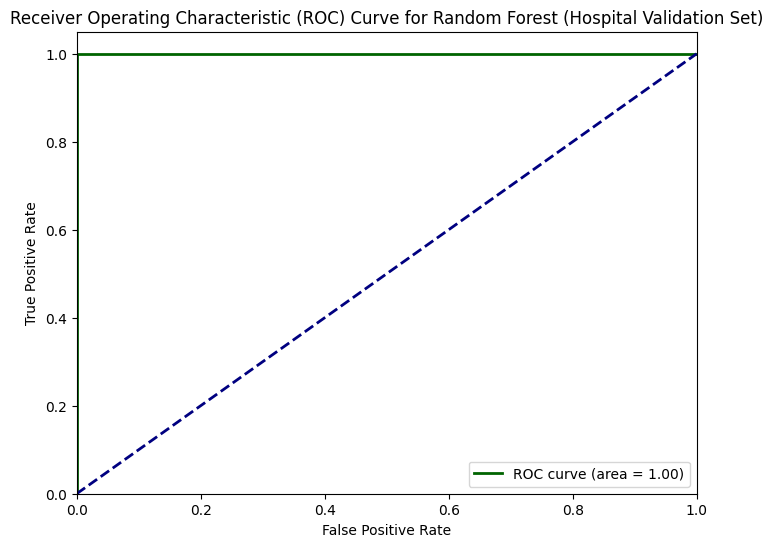

Random Forest (Hospital Validation) ROC AUC: 1.0000


In [62]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

if y_pred_proba_rf_hospital_pca.shape[1] == 2:
    y_scores_rf_hospital_pca_val = y_pred_proba_rf_hospital_pca[:, 1]
else:
    y_scores_rf_hospital_pca_val = y_pred_proba_rf_hospital_pca.ravel() # Fallback, though unlikely for this model

fpr_rf_hospital_pca, tpr_rf_hospital_pca, thresholds_rf_hospital_pca = roc_curve(y_val_hospital, y_scores_rf_hospital_pca_val)
roc_auc_rf_hospital_pca = auc(fpr_rf_hospital_pca, tpr_rf_hospital_pca)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf_hospital_pca, tpr_rf_hospital_pca, color='darkgreen', lw=2, label=f'ROC curve (area = {roc_auc_rf_hospital_pca:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Random Forest (Hospital Validation Set)')
plt.legend(loc='lower right')
plt.show()

print(f"Random Forest (Hospital Validation) ROC AUC: {roc_auc_rf_hospital_pca:.4f}")

### Final Evaluation of Random Forest on Hospital Test Set

In [63]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

print("\n------ Evaluating Random Forest Model on Hospital Test Set ------")

#  predictions o
y_pred_rf_hospital_test = rf_model_hospital_pca.predict(X_test_hospital_pca)
y_pred_proba_rf_hospital_test = rf_model_hospital_pca.predict_proba(X_test_hospital_pca)

#  performance metrics
accuracy_rf_hospital_test = accuracy_score(y_test_hospital, y_pred_rf_hospital_test)
precision_rf_hospital_test = precision_score(y_test_hospital, y_pred_rf_hospital_test, average='weighted', zero_division=0)
recall_rf_hospital_test = recall_score(y_test_hospital, y_pred_rf_hospital_test, average='weighted', zero_division=0)
f1_rf_hospital_test = f1_score(y_test_hospital, y_pred_rf_hospital_test, average='weighted', zero_division=0)

# ROC AUC
roc_auc_rf_hospital_test = None
if hasattr(rf_model_hospital_pca, 'predict_proba') and len(rf_model_hospital_pca.classes_) == 2:
    roc_auc_rf_hospital_test = roc_auc_score(y_test_hospital, y_pred_proba_rf_hospital_test[:, 1])

print(f"  Accuracy: {accuracy_rf_hospital_test:.4f}")
print(f"  Precision (weighted): {precision_rf_hospital_test:.4f}")
print(f"  Recall (weighted): {recall_rf_hospital_test:.4f}")
print(f"  F1-Score (weighted): {f1_rf_hospital_test:.4f}")
if roc_auc_rf_hospital_test is not None:
    print(f"  ROC AUC: {roc_auc_rf_hospital_test:.4f}")
print("  Confusion Matrix:\n", confusion_matrix(y_test_hospital, y_pred_rf_hospital_test))
print("  Classification Report:\n", classification_report(y_test_hospital, y_pred_rf_hospital_test, zero_division=0))

print("\n------ Hospital Test Set Evaluation Complete. ------")


------ Evaluating Random Forest Model on Hospital Test Set ------
  Accuracy: 1.0000
  Precision (weighted): 1.0000
  Recall (weighted): 1.0000
  F1-Score (weighted): 1.0000
  ROC AUC: 1.0000
  Confusion Matrix:
 [[1877    0]
 [   0  976]]
  Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1877
           1       1.00      1.00      1.00       976

    accuracy                           1.00      2853
   macro avg       1.00      1.00      1.00      2853
weighted avg       1.00      1.00      1.00      2853


------ Hospital Test Set Evaluation Complete. ------


### ROC

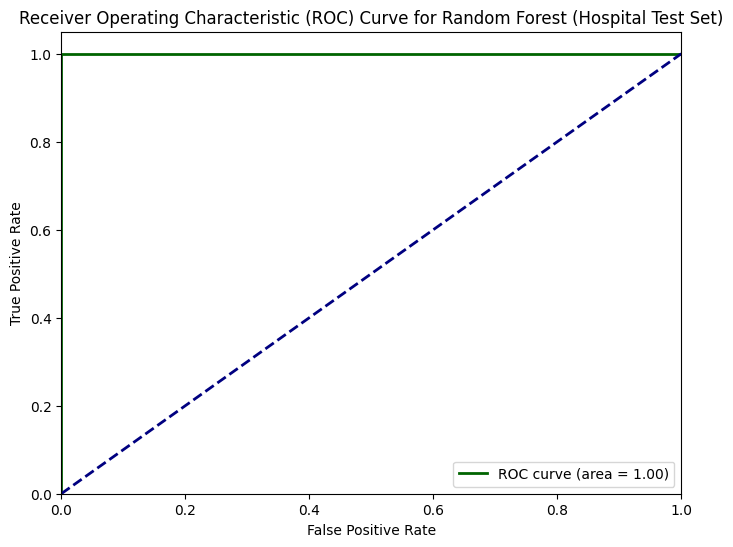

Random Forest (Hospital Test) ROC AUC: 1.0000


In [64]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

if y_pred_proba_rf_hospital_test.shape[1] == 2:
    y_scores_rf_hospital_test = y_pred_proba_rf_hospital_test[:, 1]
else:
    y_scores_rf_hospital_test = y_pred_proba_rf_hospital_test.ravel() # Fallback, though unlikely for this model

fpr_rf_hospital_test, tpr_rf_hospital_test, thresholds_rf_hospital_test = roc_curve(y_test_hospital, y_scores_rf_hospital_test)
roc_auc_rf_hospital_test = auc(fpr_rf_hospital_test, tpr_rf_hospital_test)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf_hospital_test, tpr_rf_hospital_test, color='darkgreen', lw=2, label=f'ROC curve (area = {roc_auc_rf_hospital_test:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Random Forest (Hospital Test Set)')
plt.legend(loc='lower right')
plt.show()

print(f"Random Forest (Hospital Test) ROC AUC: {roc_auc_rf_hospital_test:.4f}")